<a href="https://www.kaggle.com/code/kedhareswernaidu/house-price-predictions?scriptVersionId=228641019" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background-color: #4CAF50; padding: 20px; border-radius: 10px; text-align: center; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.2);">
  <h1 style="color: #FFFFFF; font-family: 'Arial', sans-serif; font-size: 36px; font-weight: bold; text-transform: uppercase; letter-spacing: 2px; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.4);">
    House Price Prediction 🏡
  </h1>
  <p style="text-align: center; font-family: 'Verdana', sans-serif; font-size: 18px; color: #F0F0F0;">
  Transforming real estate data into actionable insights to forecast market trends with accuracy!
</p>
</div>


<img src="https://th.bing.com/th/id/OIP.mzSZsdo8lKkahN5S-Uk_qAHaEK?rs=1&pid=ImgDetMain" alt="House Price Prediction" style="display: block; margin: auto; border: 2px solid black; border-radius: 8px;">


<div style="background: linear-gradient(135deg, #1e3c72, #2a5298); color: #f0f8ff; font-family: 'Arial', sans-serif; font-weight: bold; text-align: center; border: 3px solid #87ceeb; border-radius: 15px; padding: 15px; width: 300px; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); margin: 20px auto;">
  Data Analysis
</div>

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

#ignoring the warnings while executing codes
import warnings
warnings.filterwarnings("ignore")

In [2]:
# importing custom matplotlib parameters for vizualizations
plt.rcParams['figure.figsize'] = (14,4)
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['figure.frameon'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams["font.family"] = "monospace";

# Color Palettes
colors = ["#bfd3e6", "#9b5b4f", "#4e4151", "#dbba78", "#bb9c55", "#909195","#dc1e1e","#a02933","#716807","#717cb4"]

In [3]:
#importing Dataset
house = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
house_test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

#checking dataset
house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
house.shape

(1460, 81)

In [5]:
house.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
house.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [8]:
# Identify numerical and categorical columns
num_cols = house.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = house.select_dtypes(include=['object']).columns.tolist()

In [9]:
# Print counts for verification
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categorical Columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fireplace

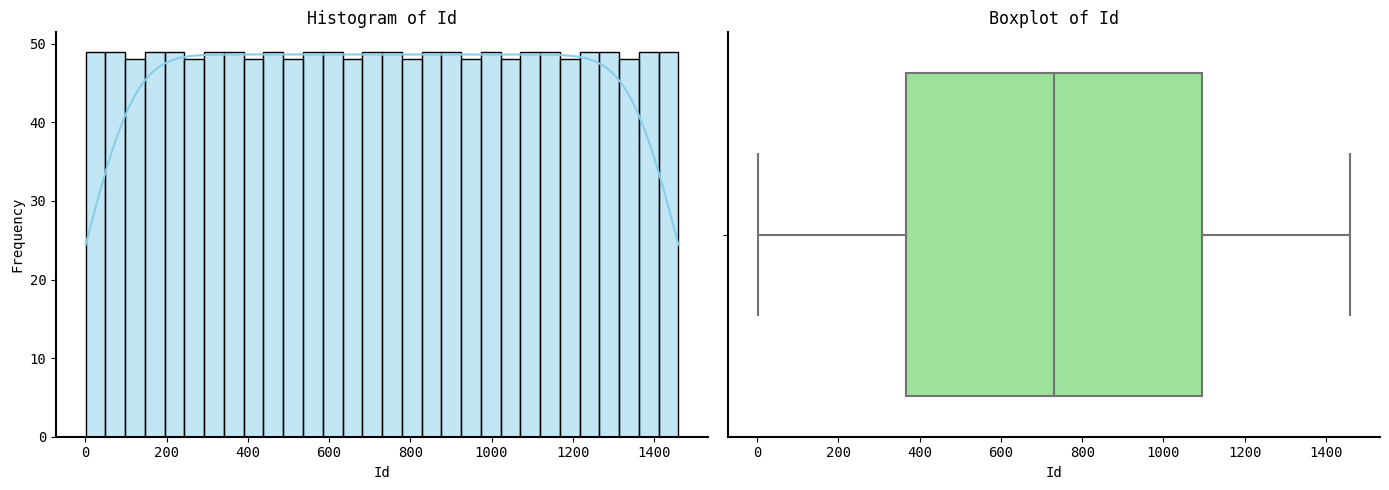

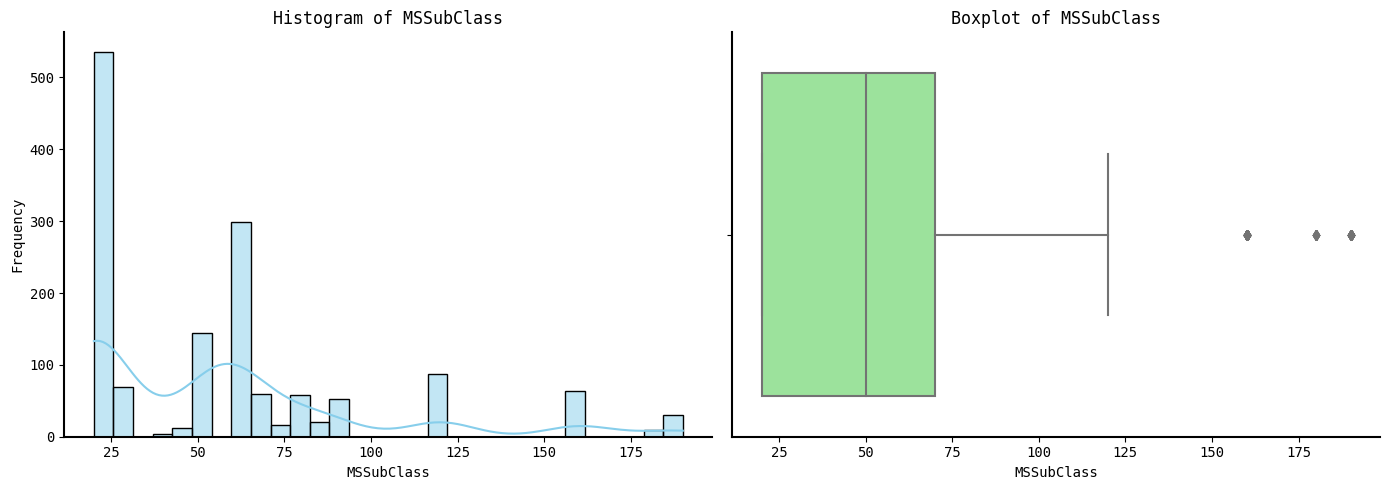

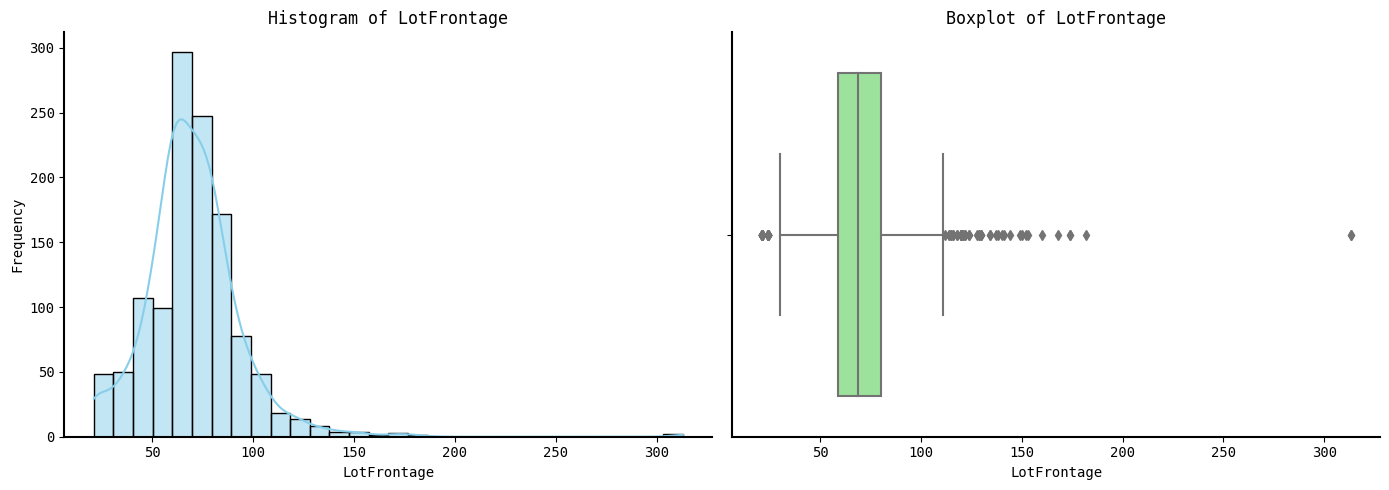

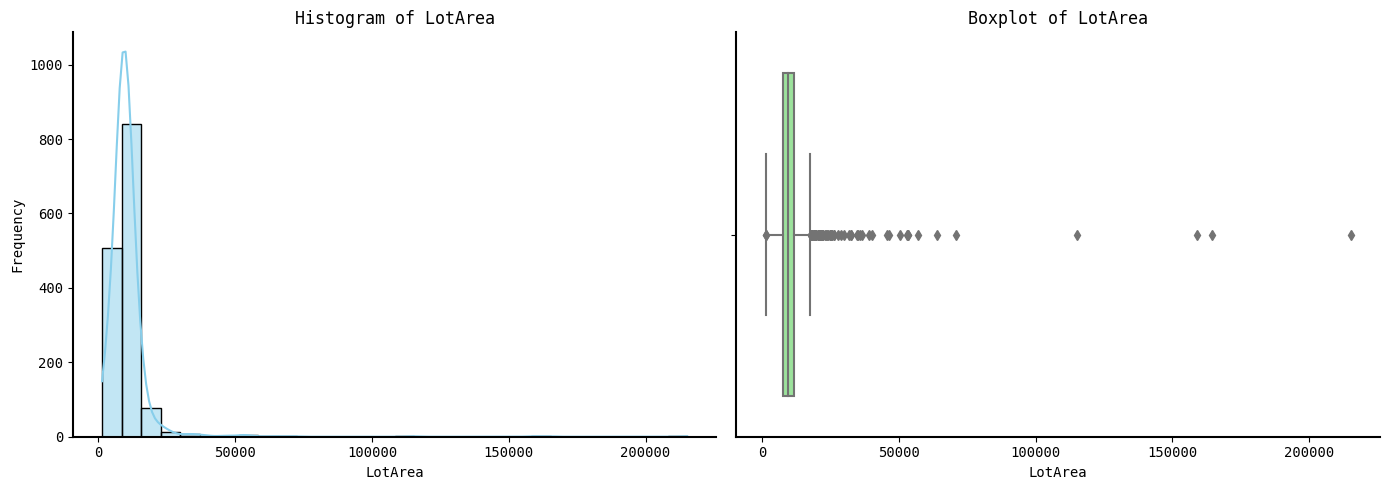

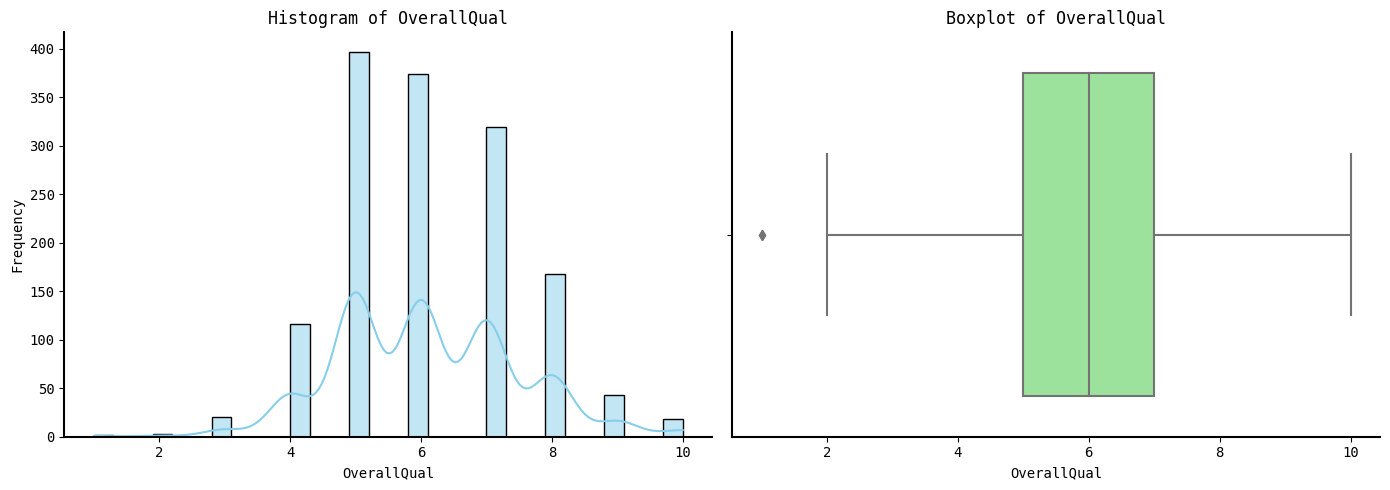

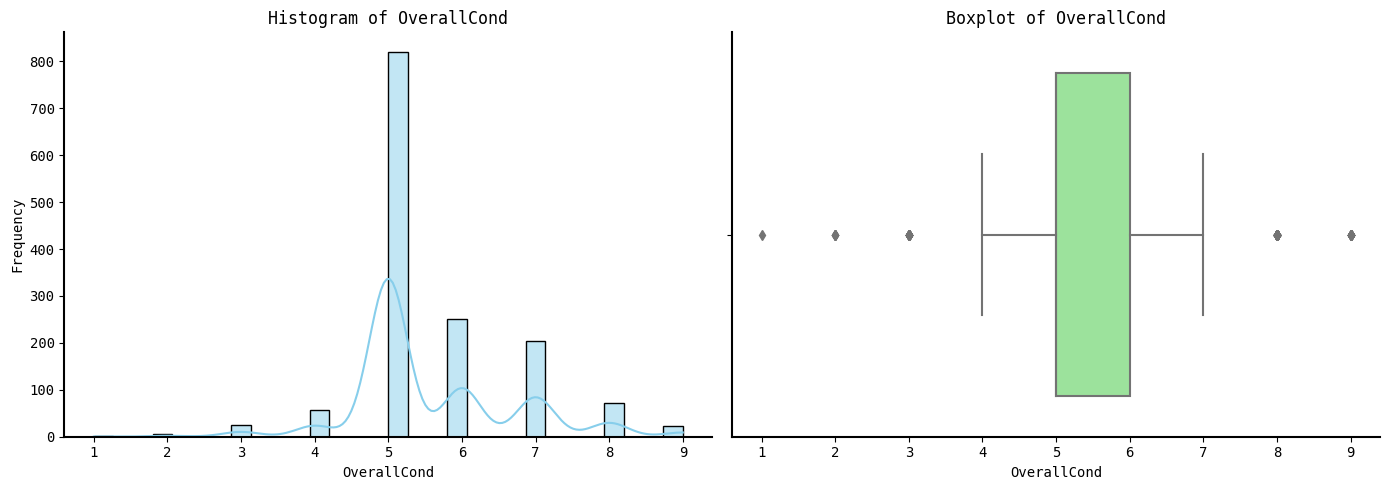

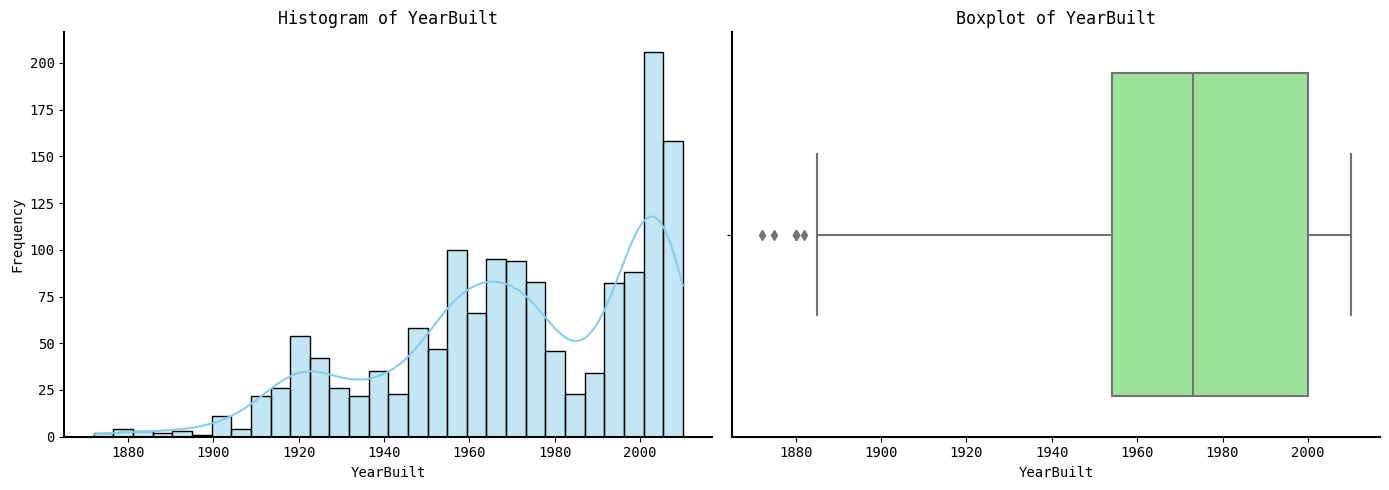

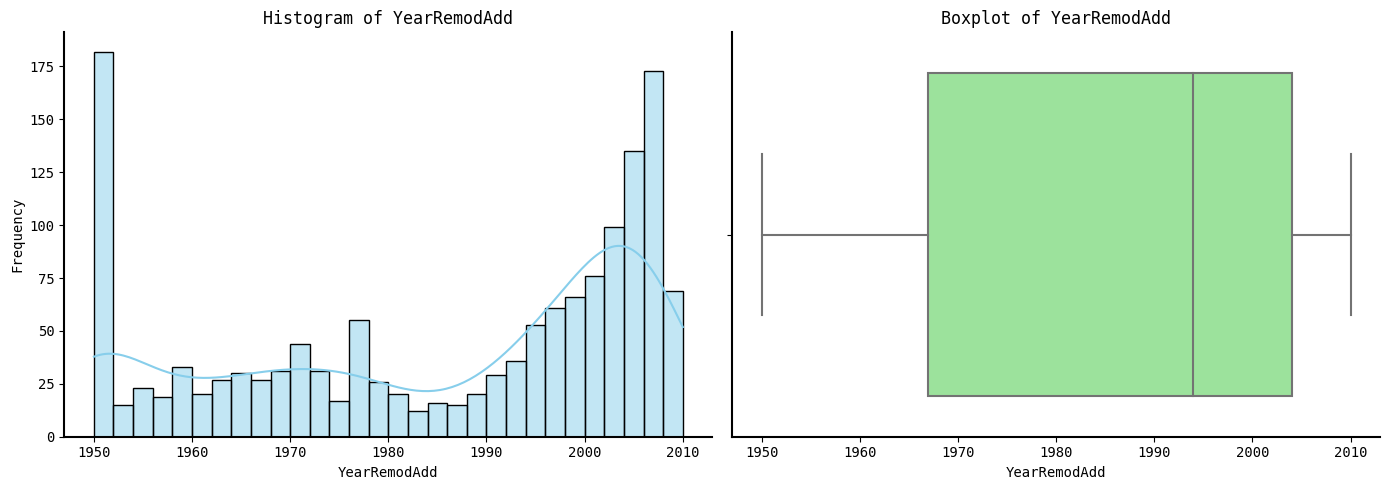

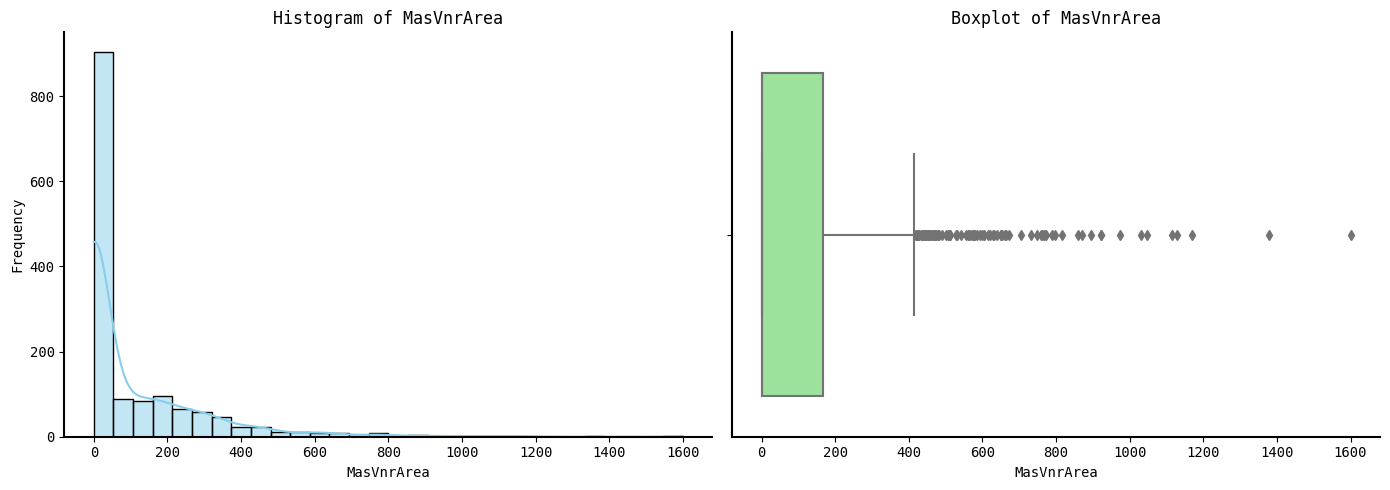

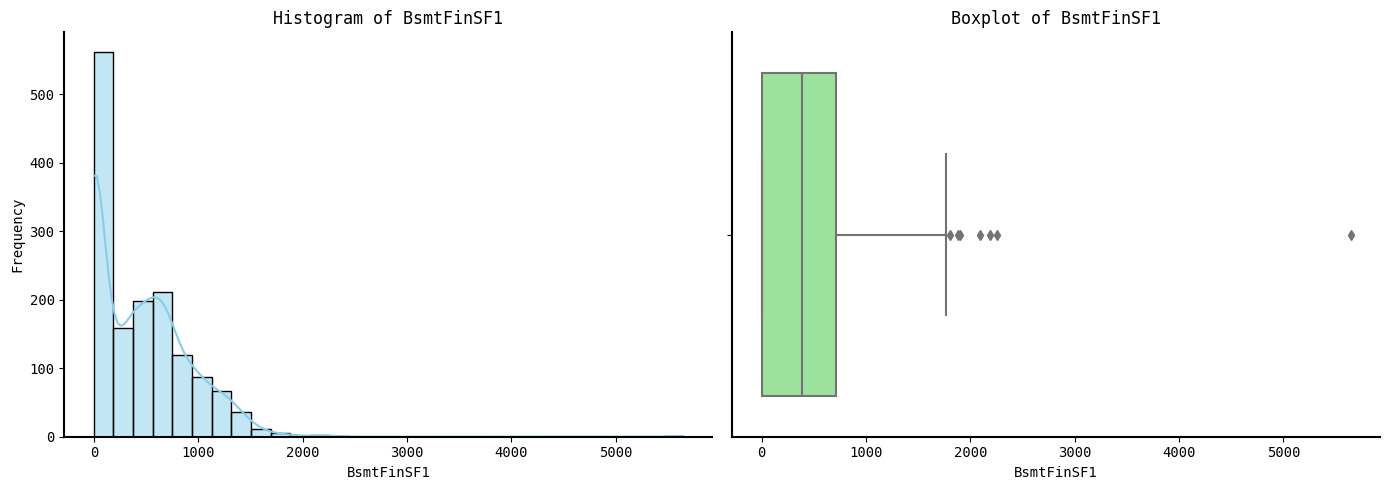

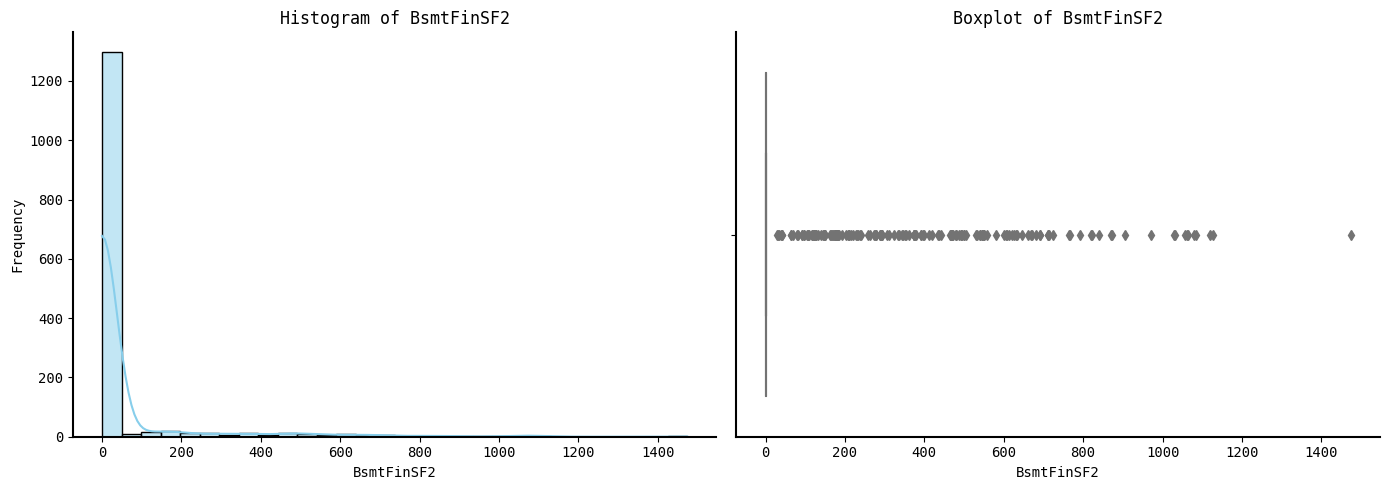

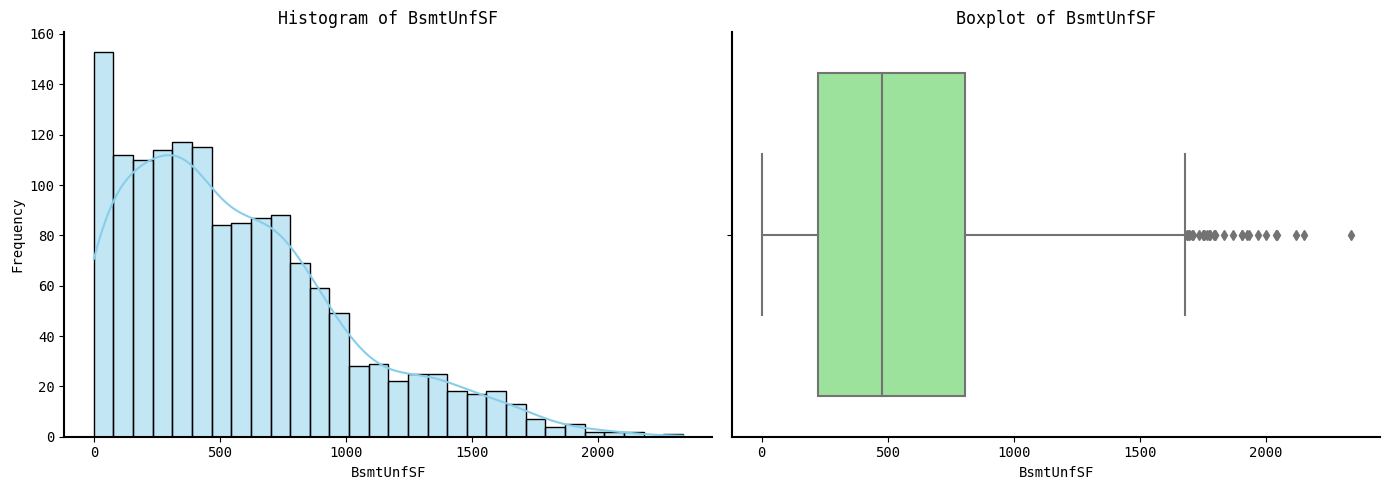

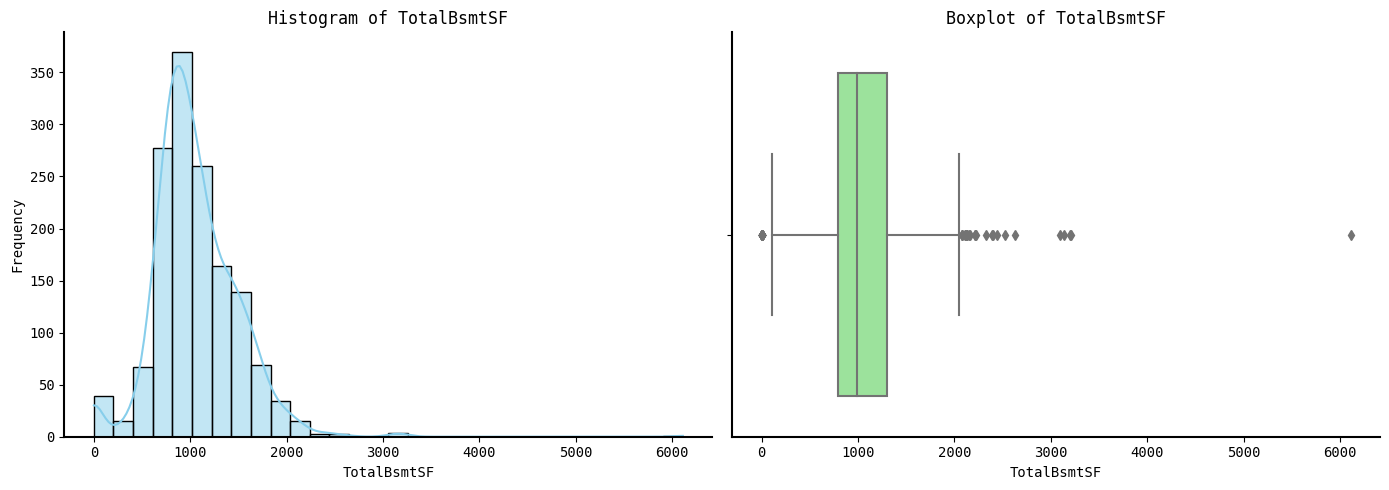

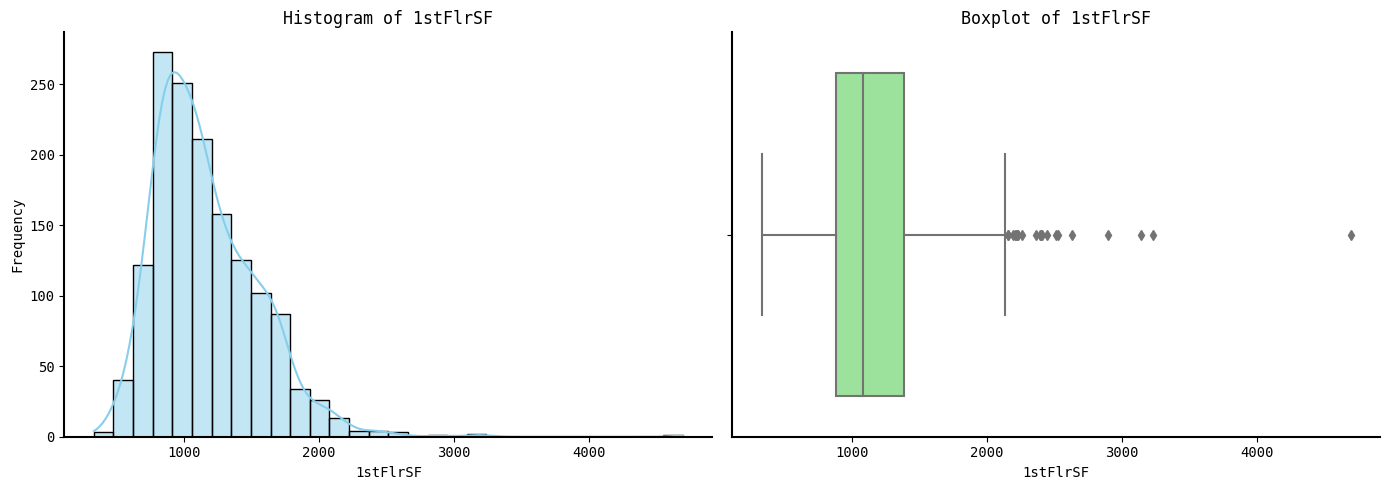

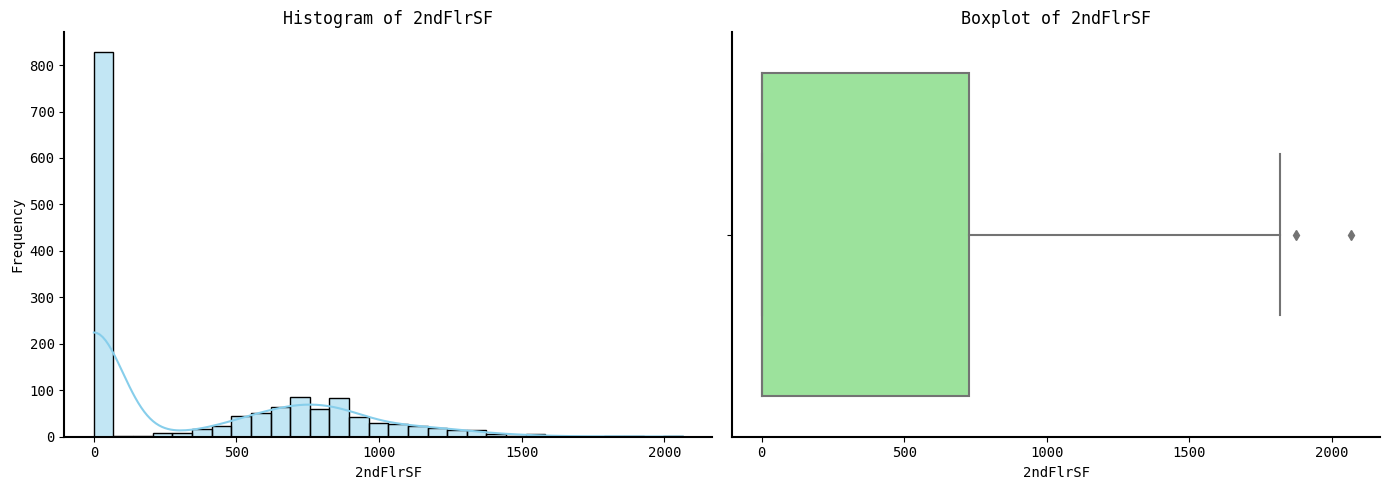

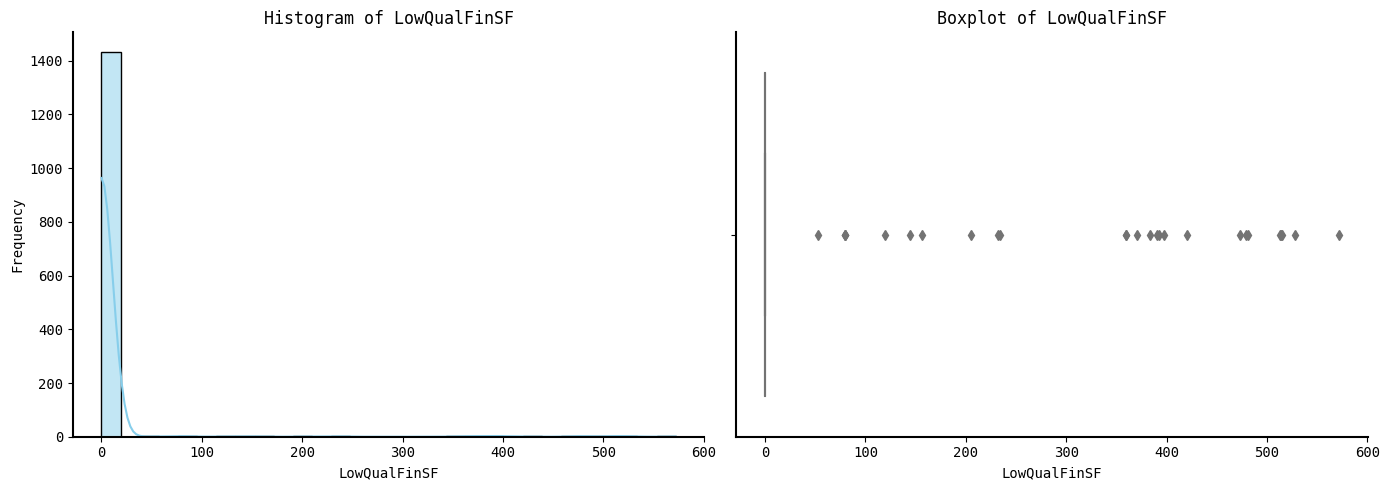

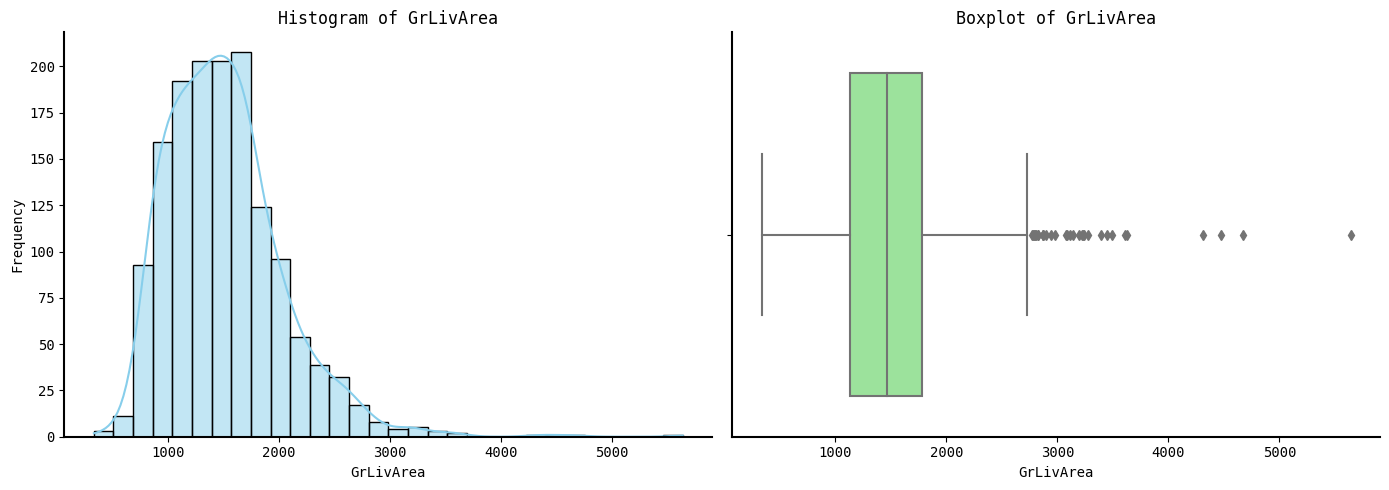

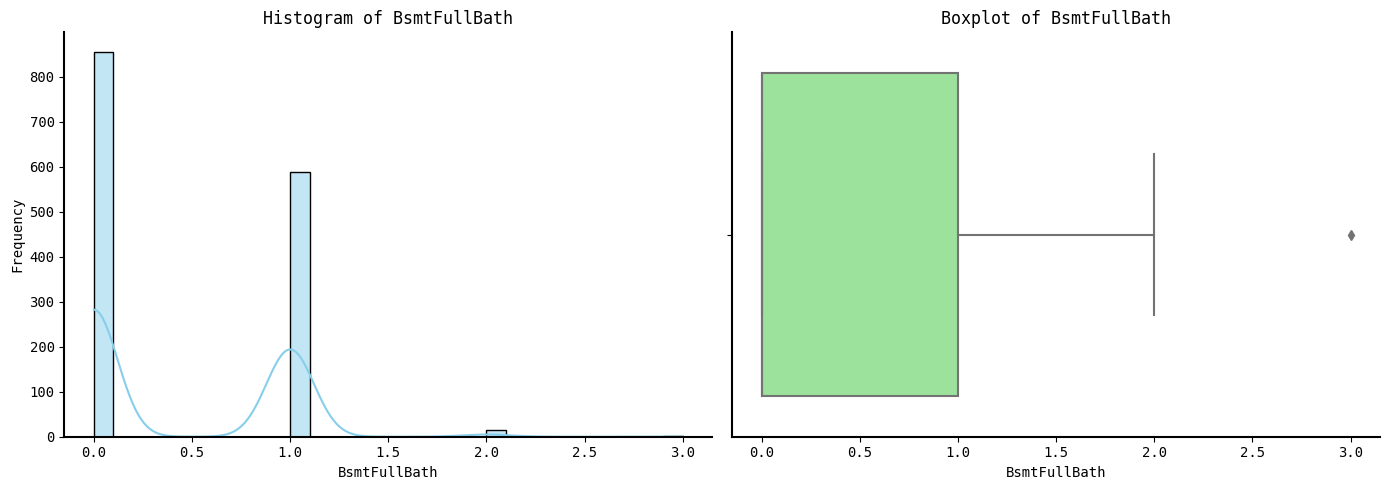

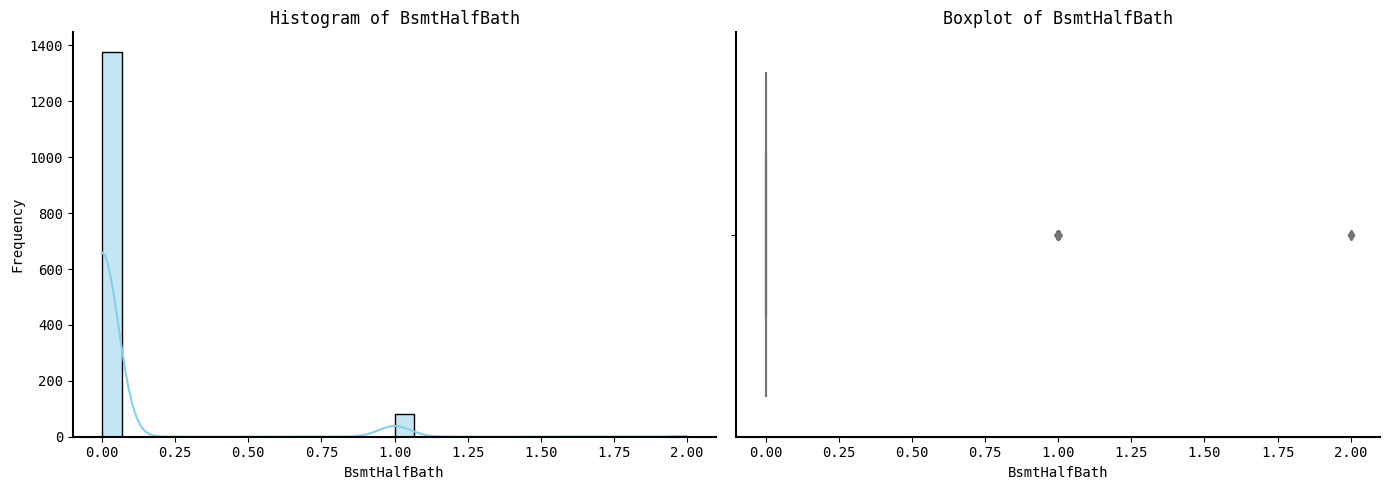

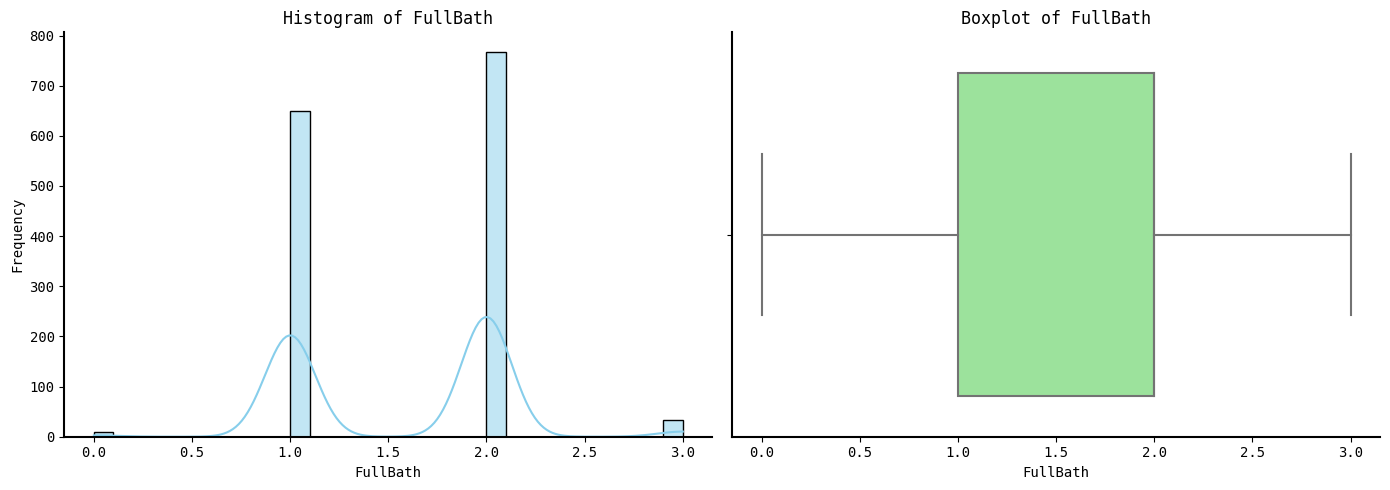

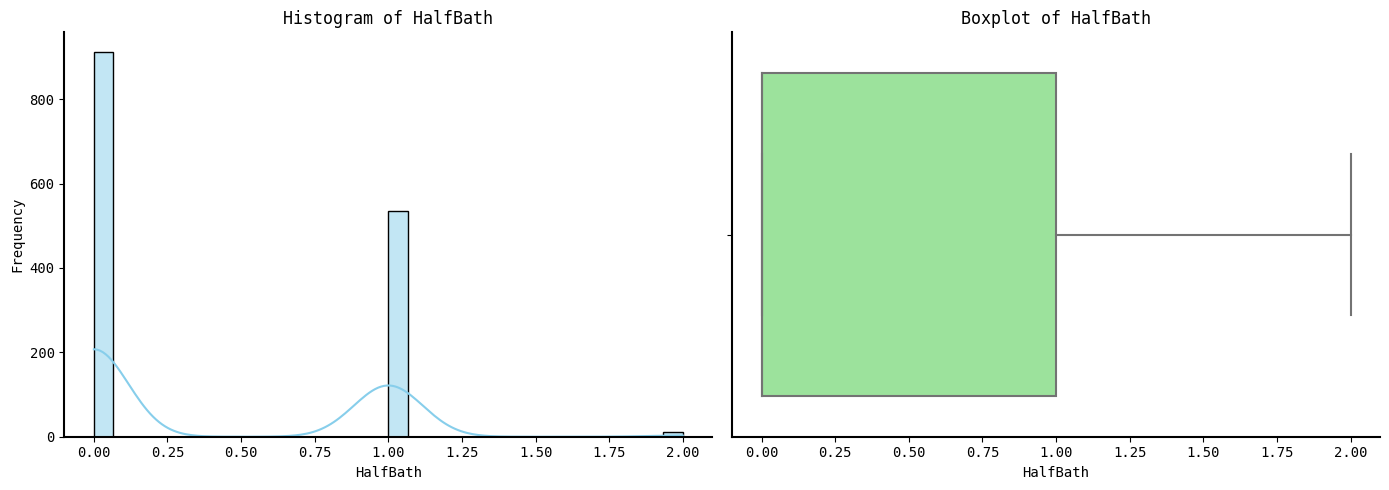

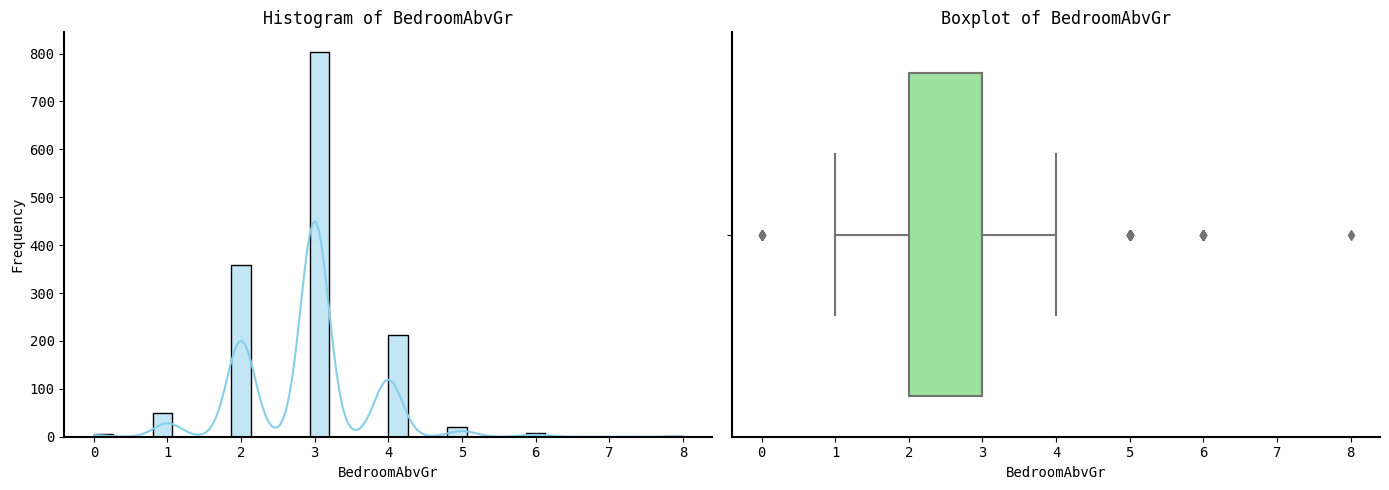

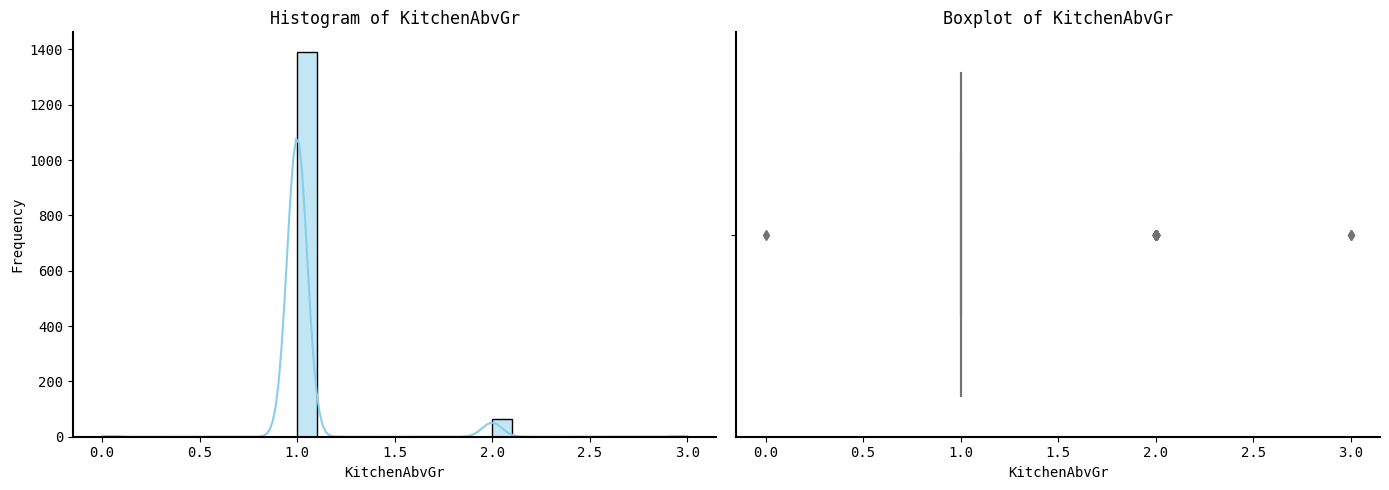

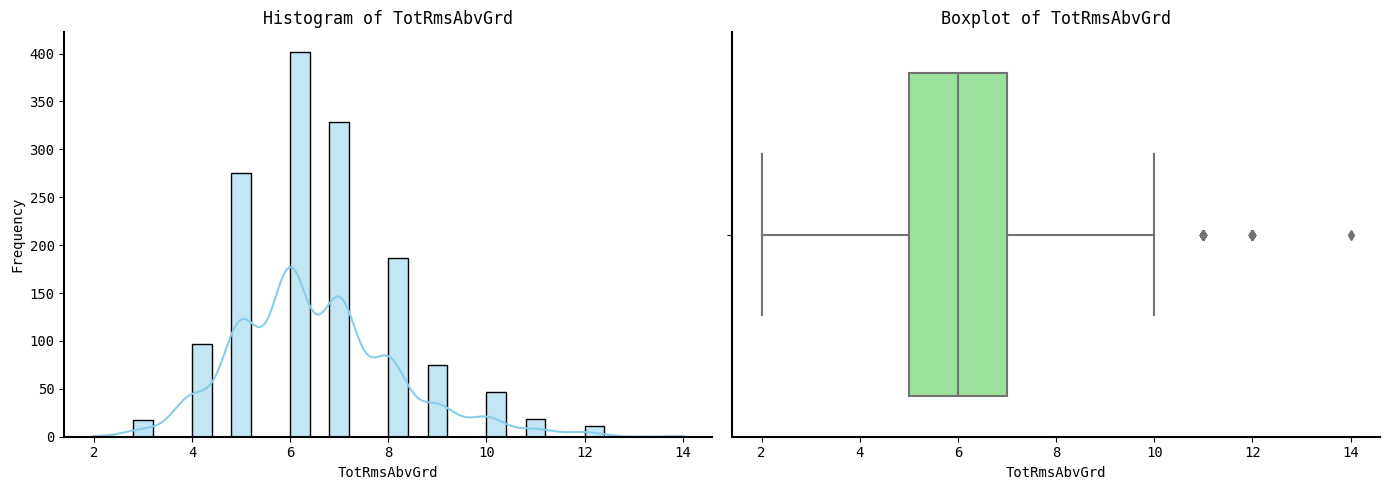

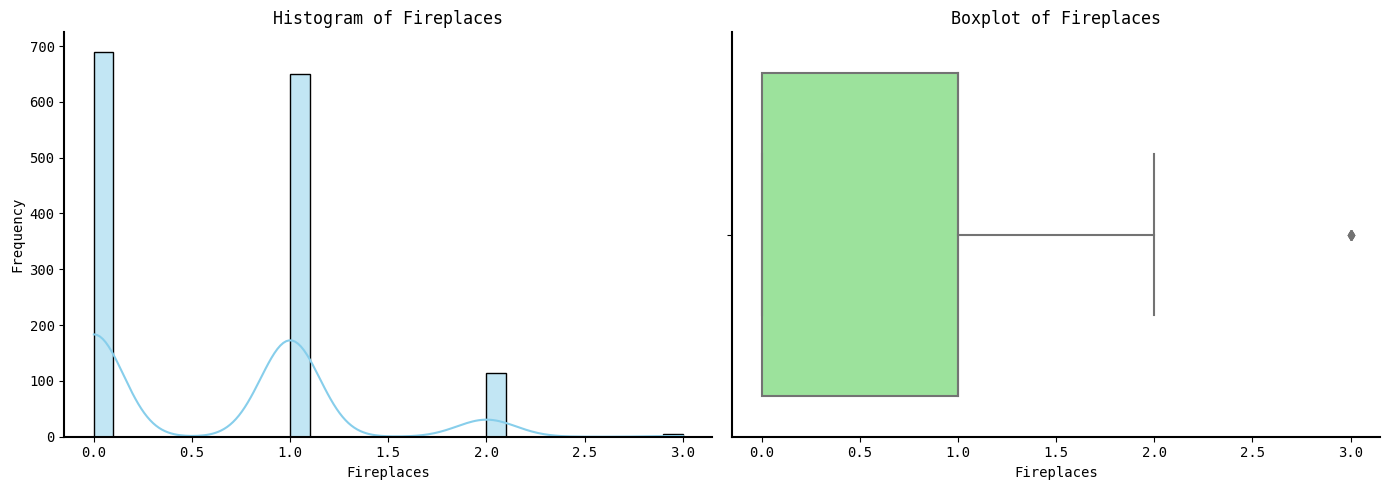

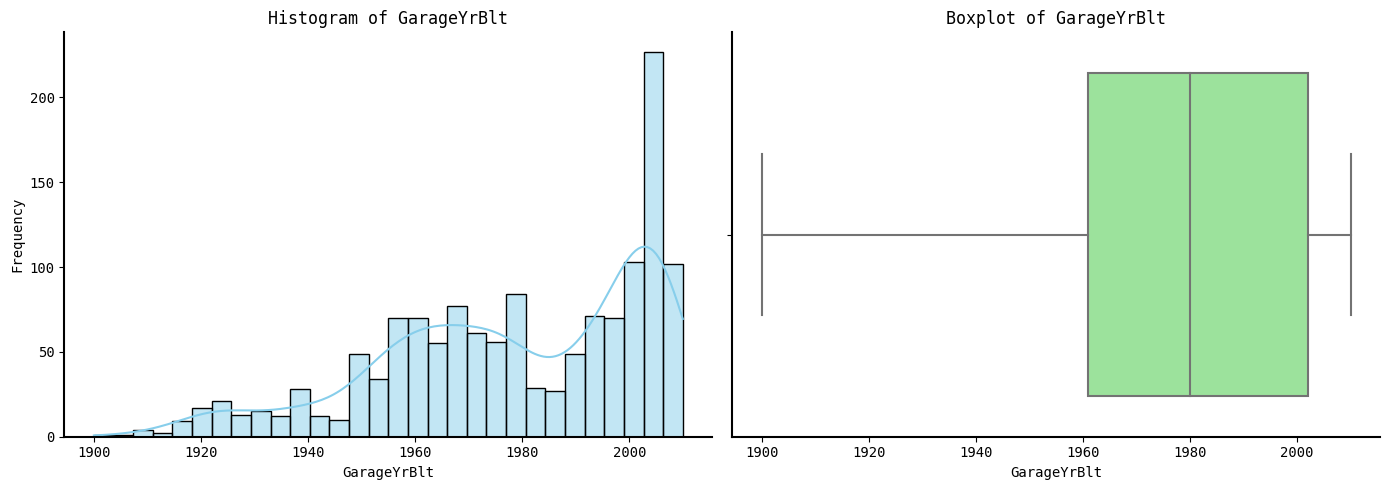

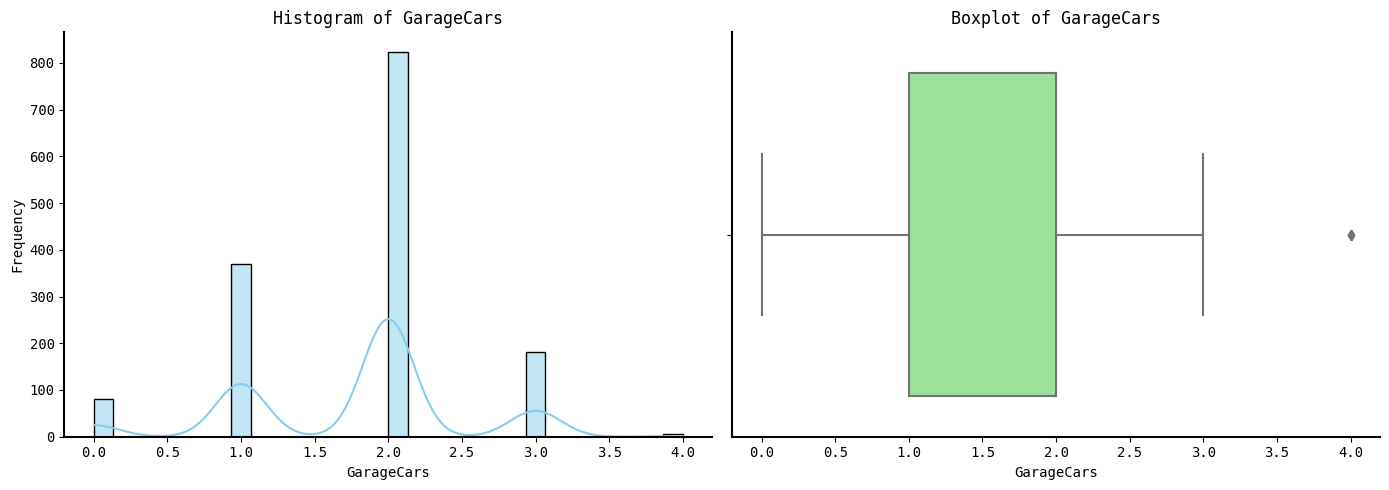

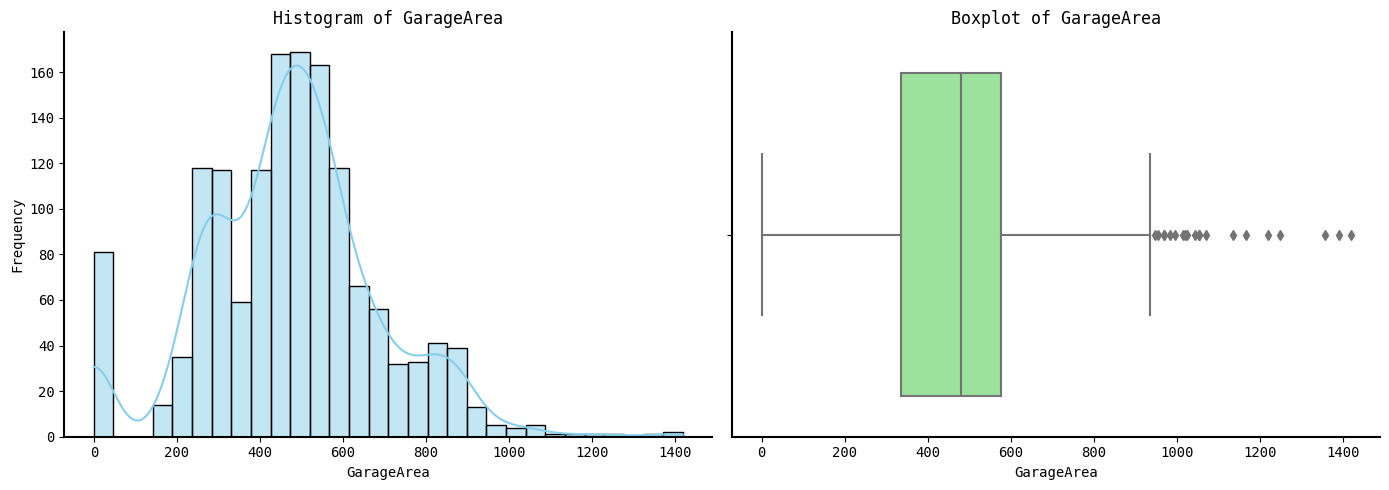

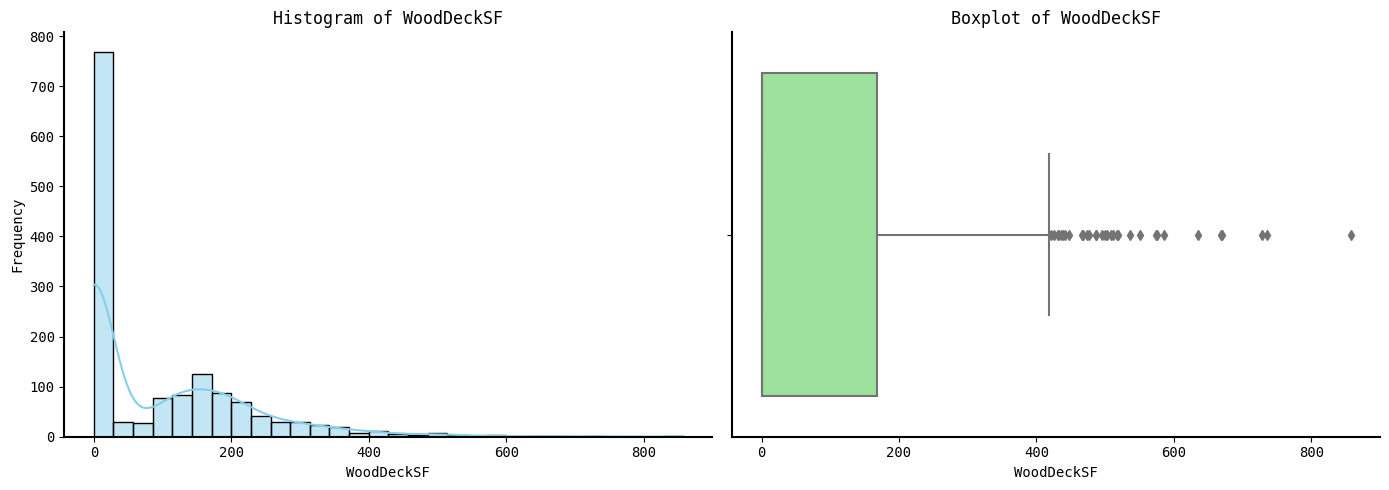

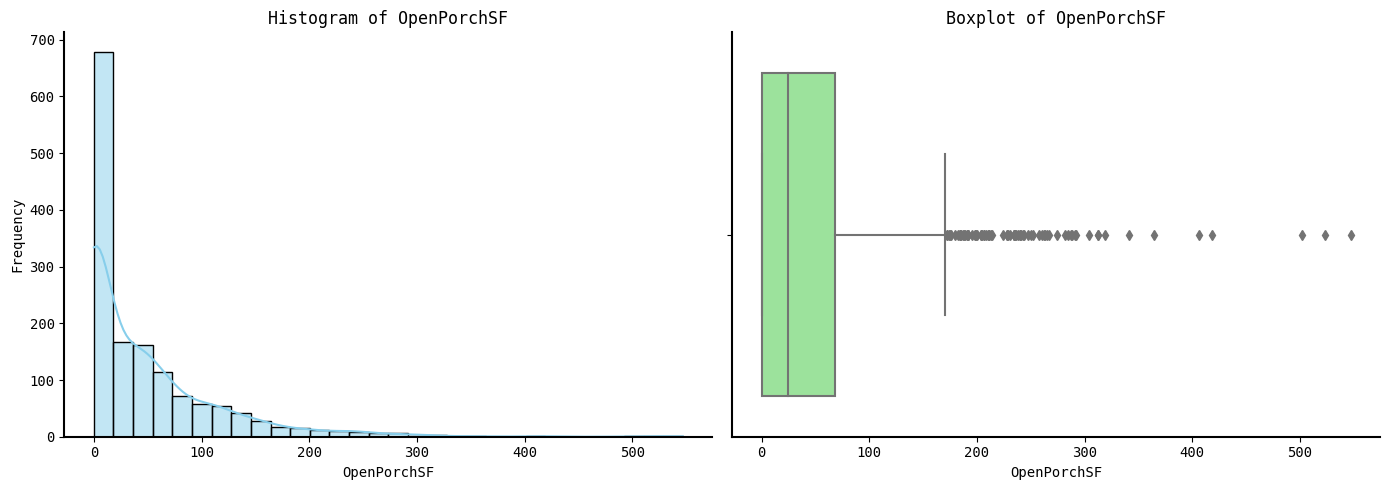

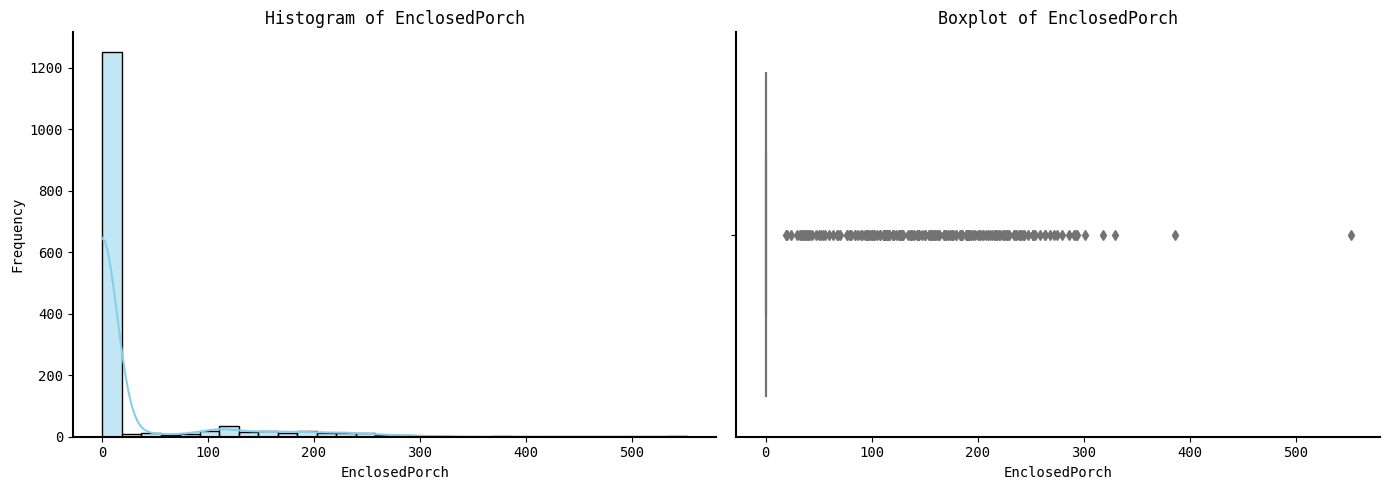

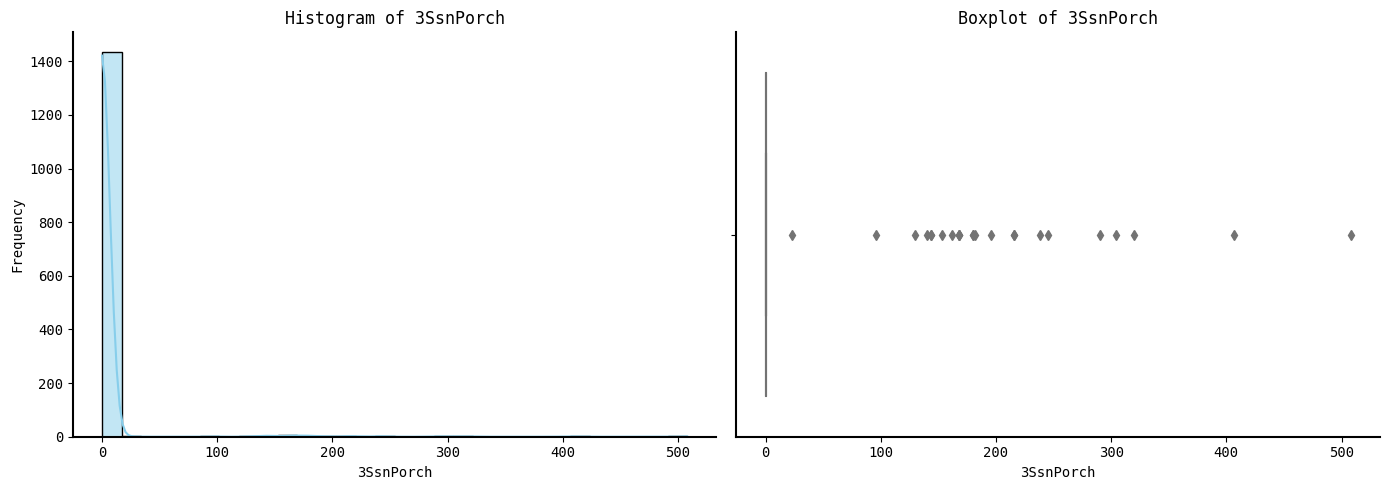

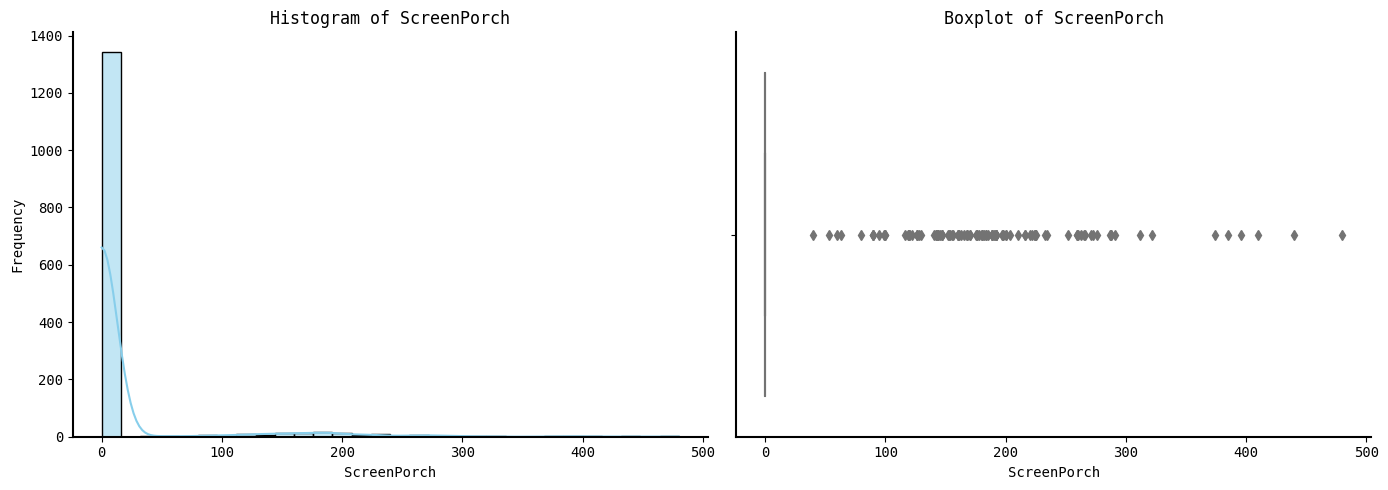

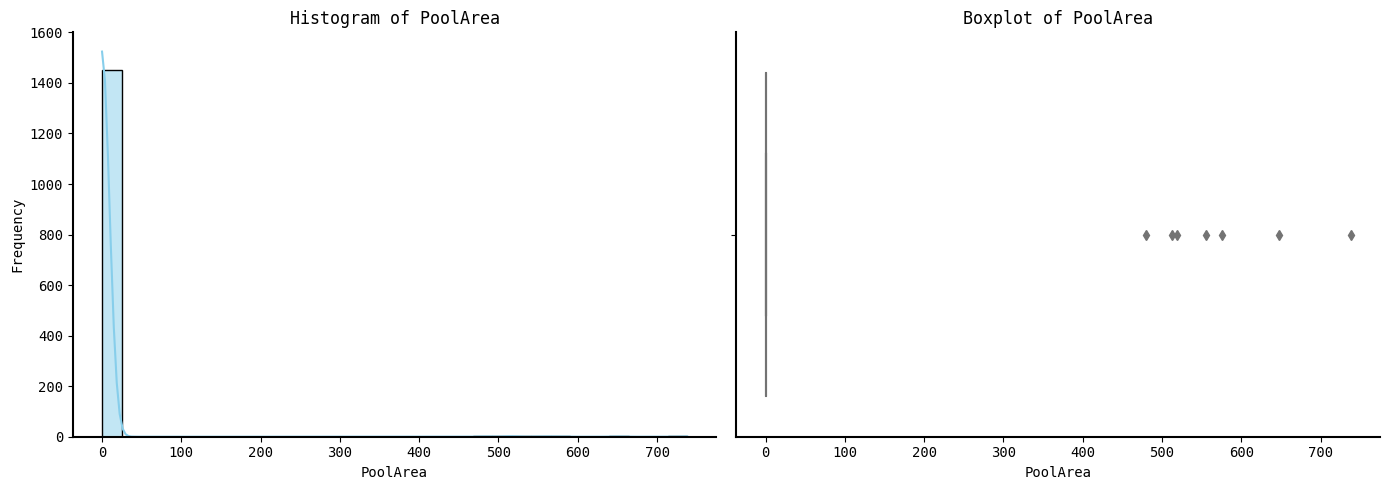

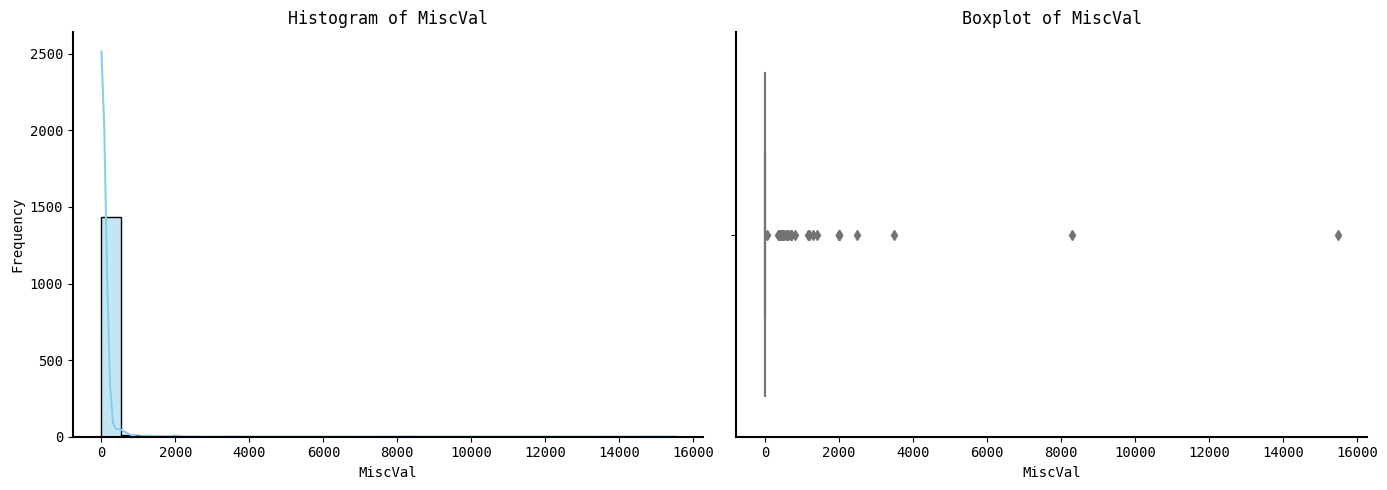

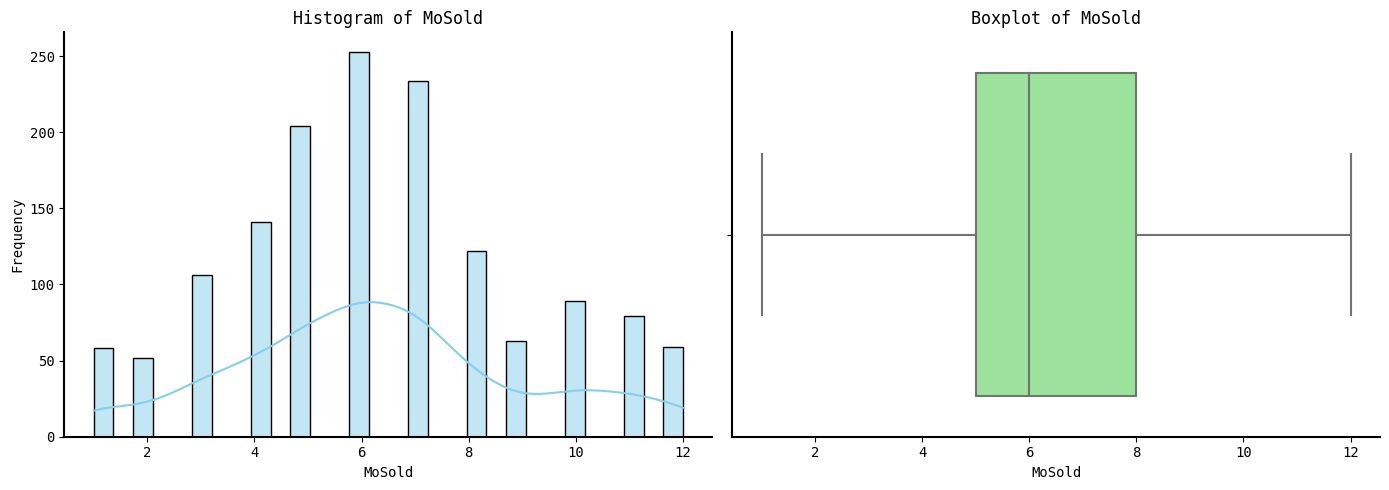

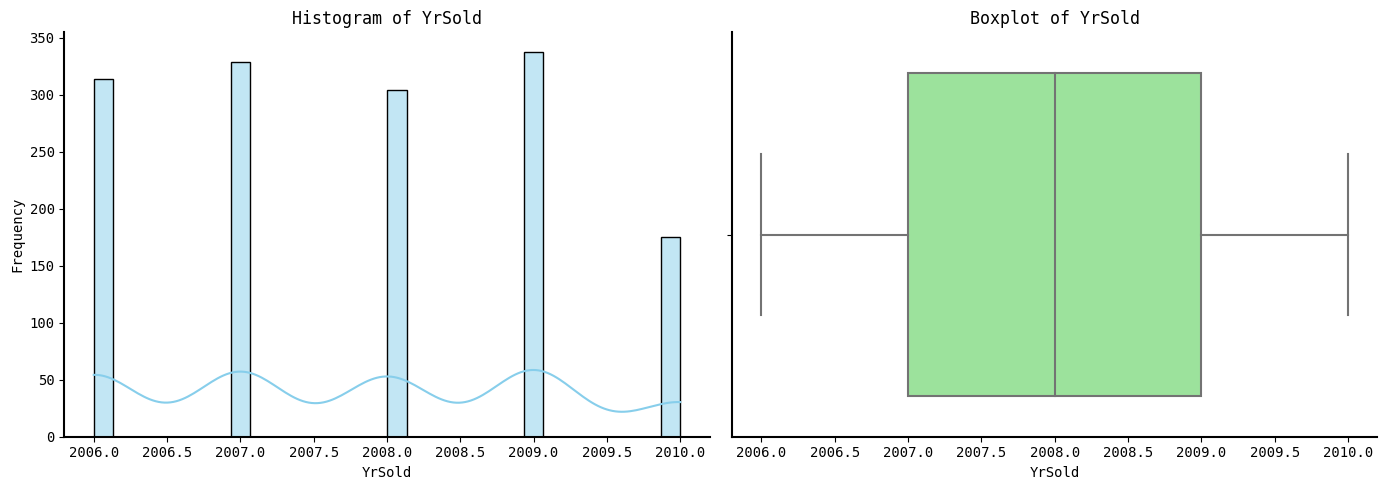

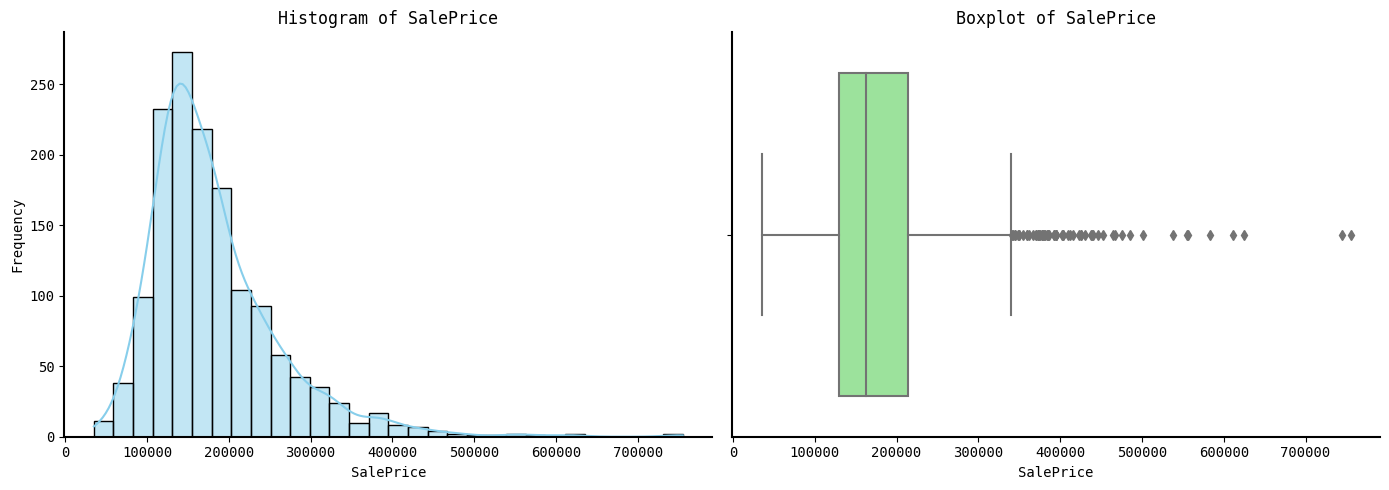

In [10]:
# For Numerical Variables: Histogram and Boxplot for each column
# --------------------------------------------------
for col in num_cols:
    # Create a new figure for each numerical column
    plt.figure(figsize=(14, 5))
    
    # Histogram with KDE
    plt.subplot(1, 2, 1)
    sns.histplot(house[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # Boxplot to inspect outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=house[col].dropna(), color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

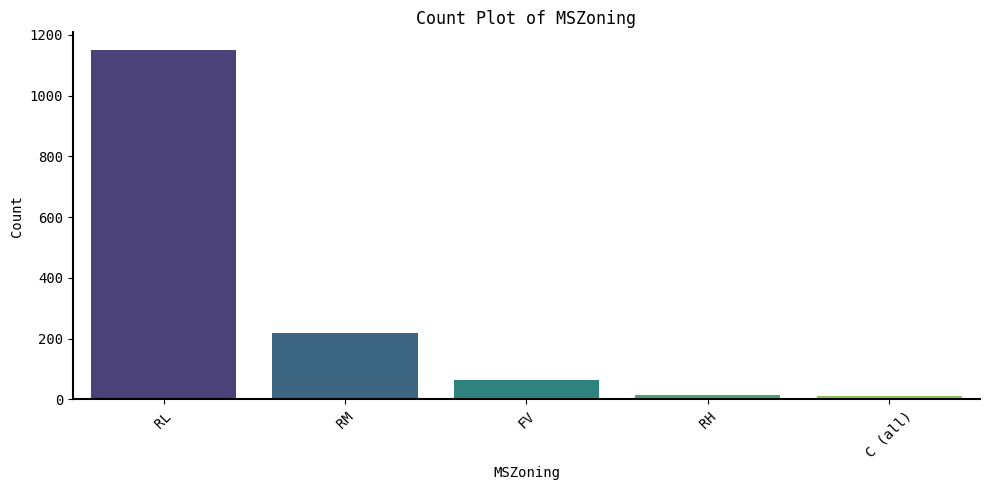

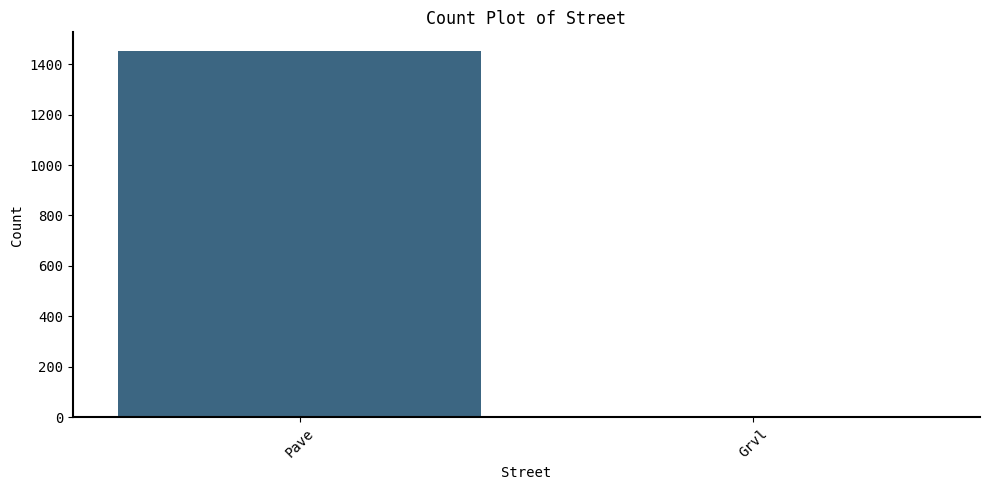

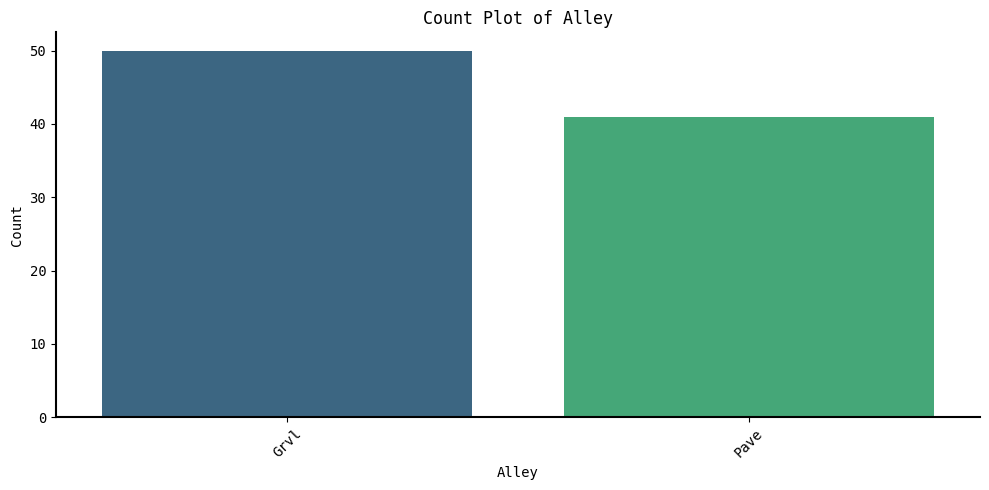

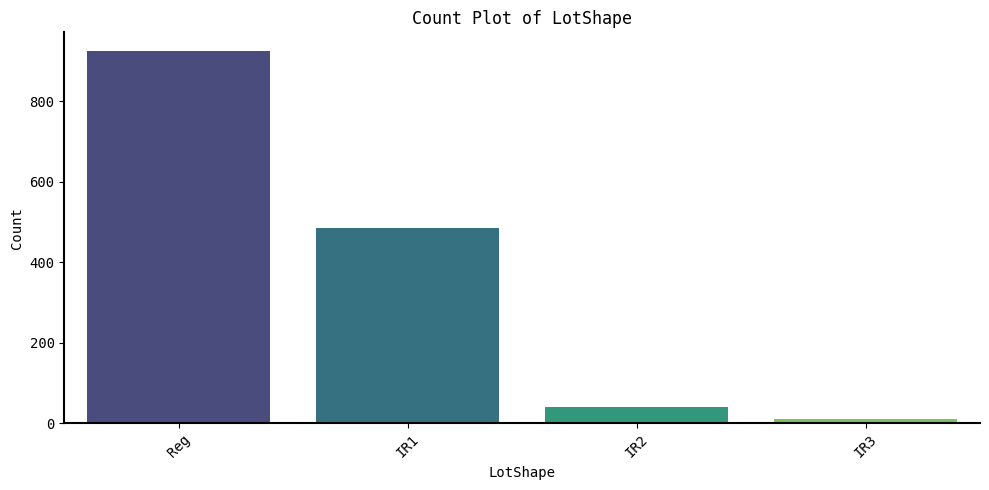

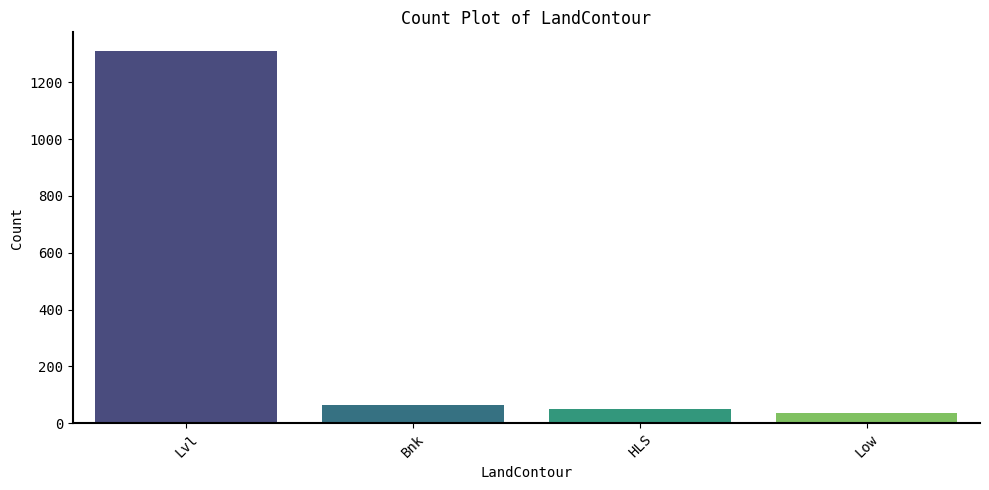

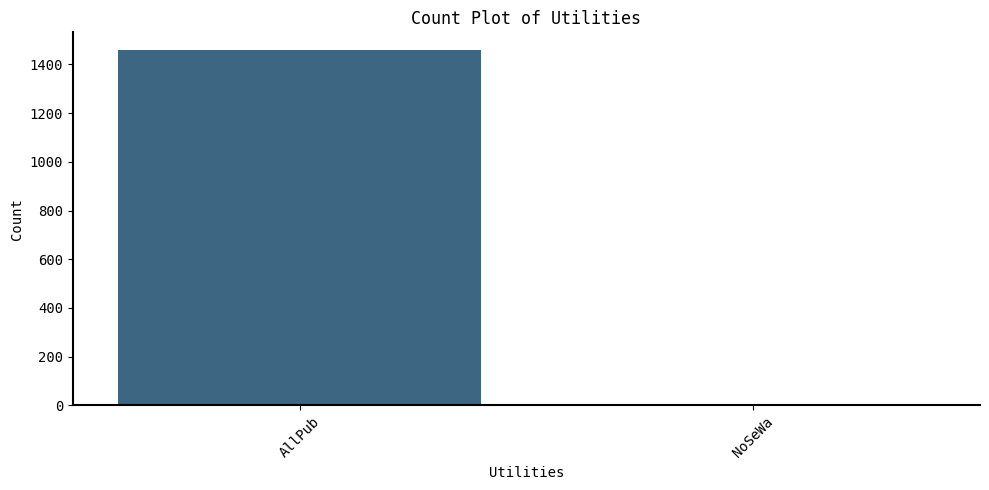

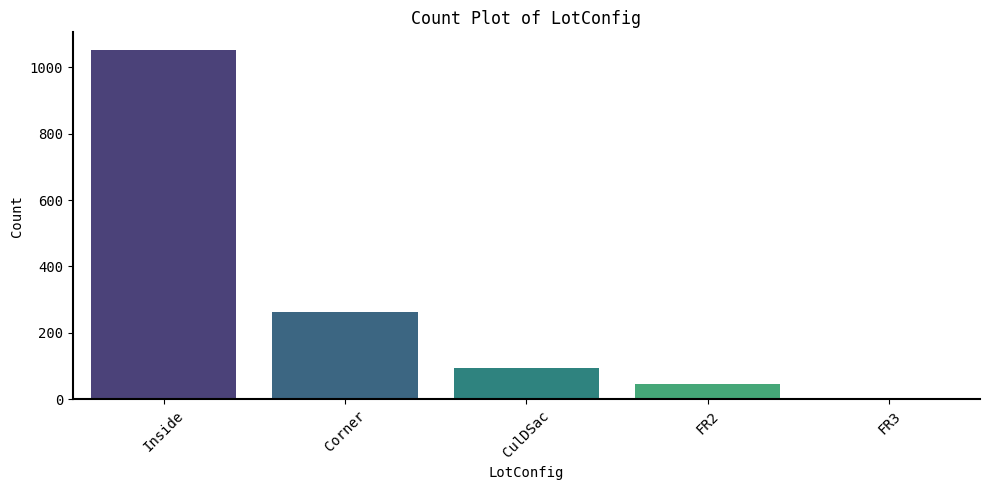

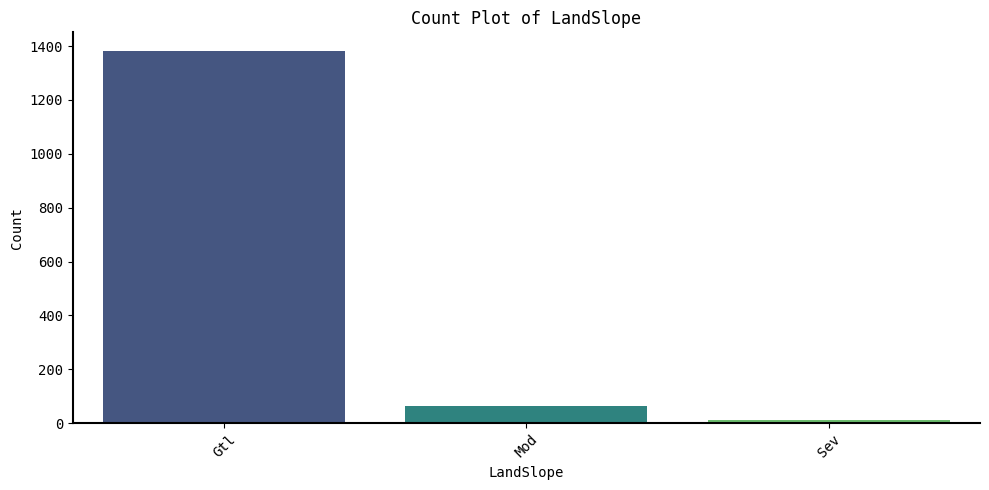

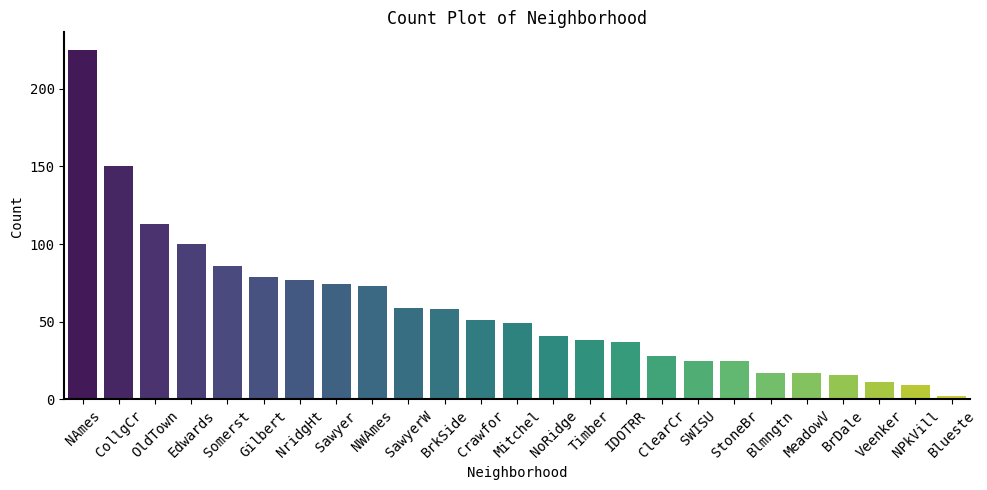

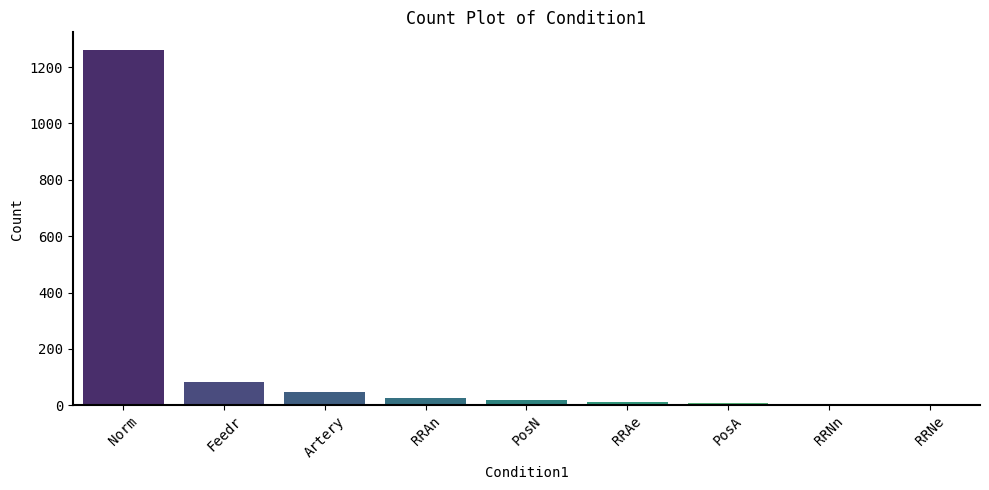

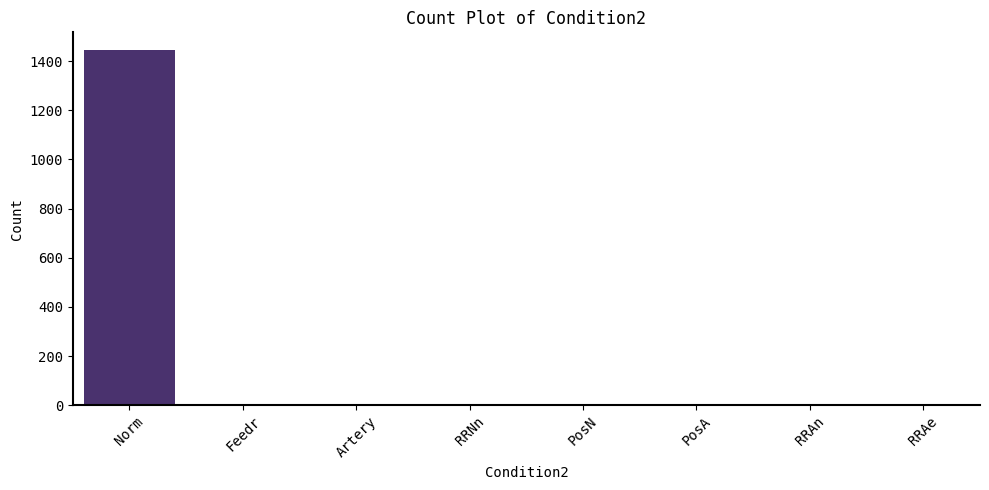

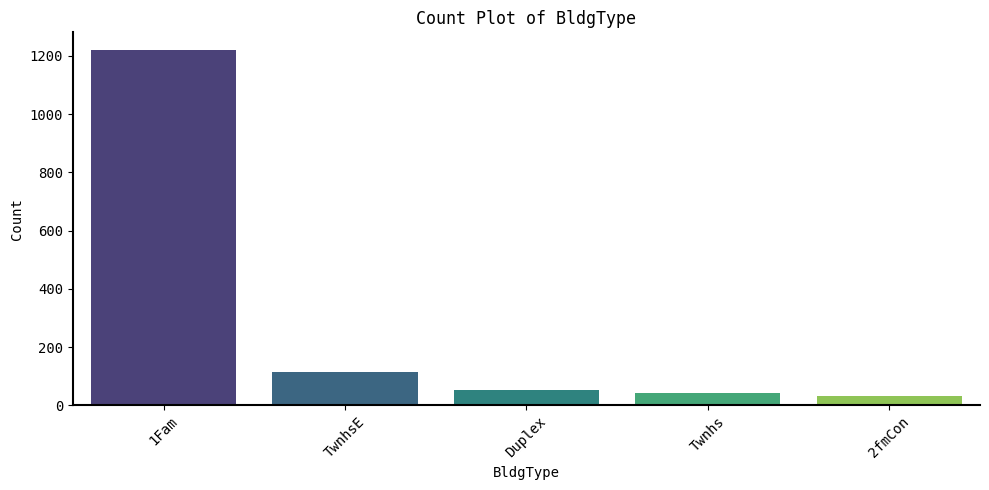

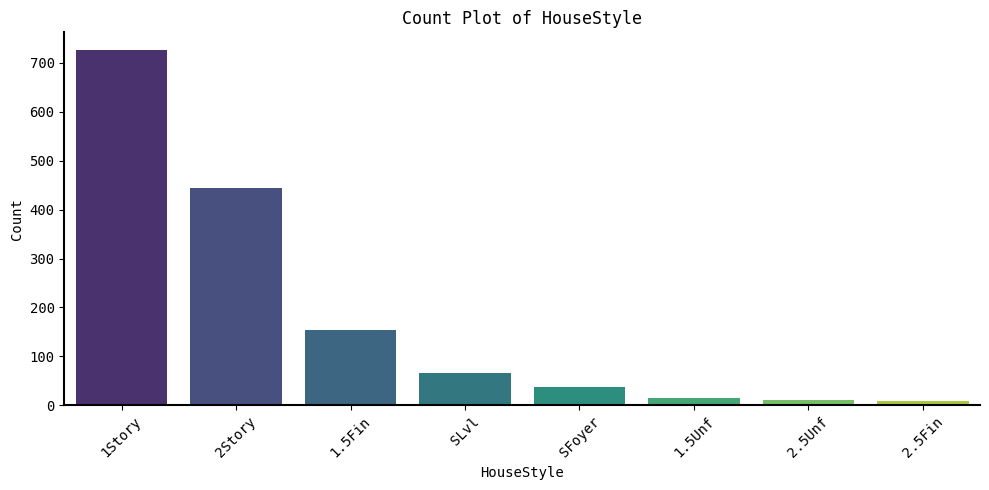

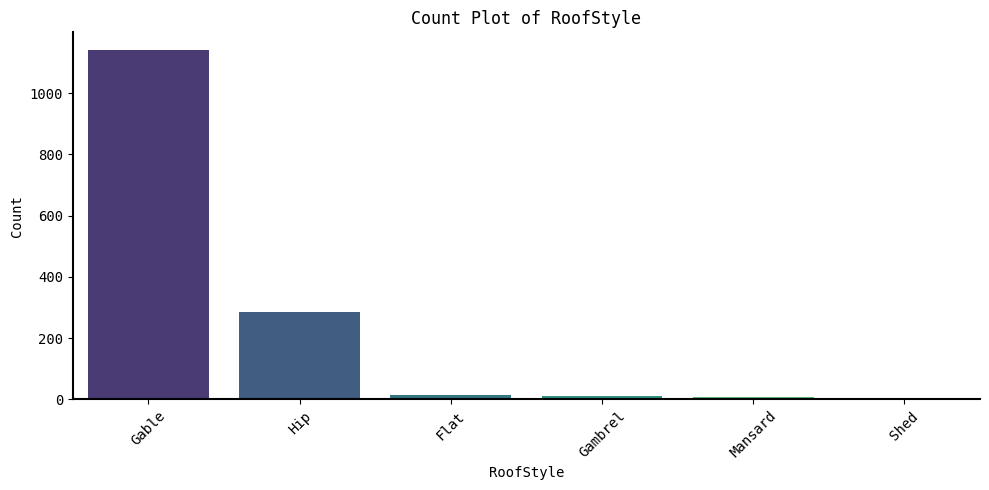

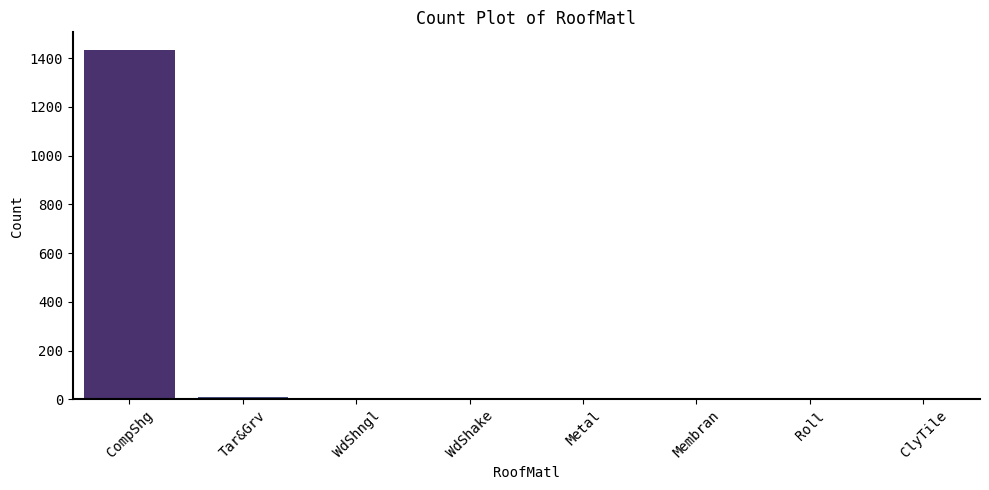

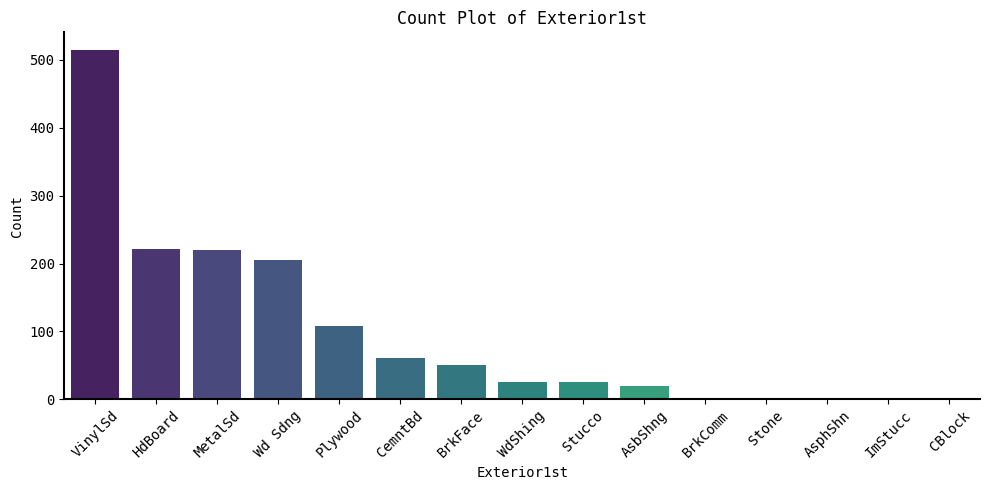

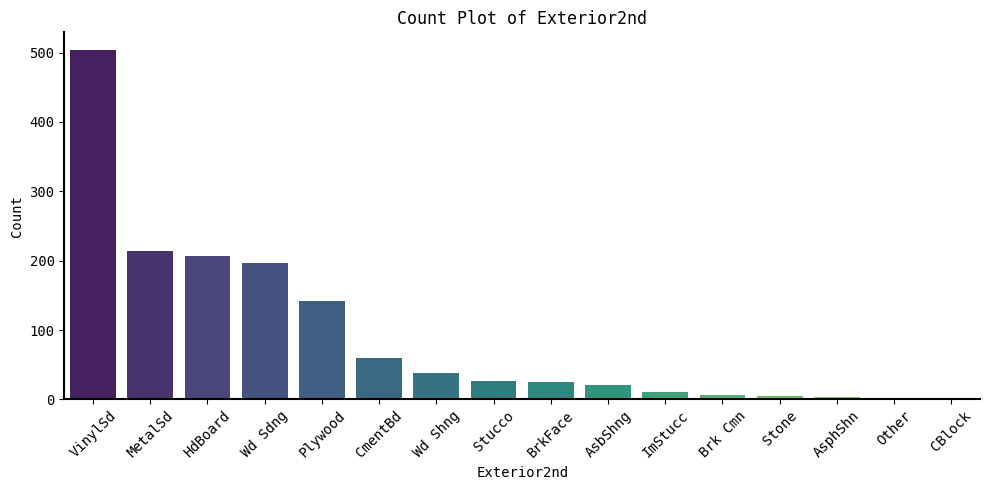

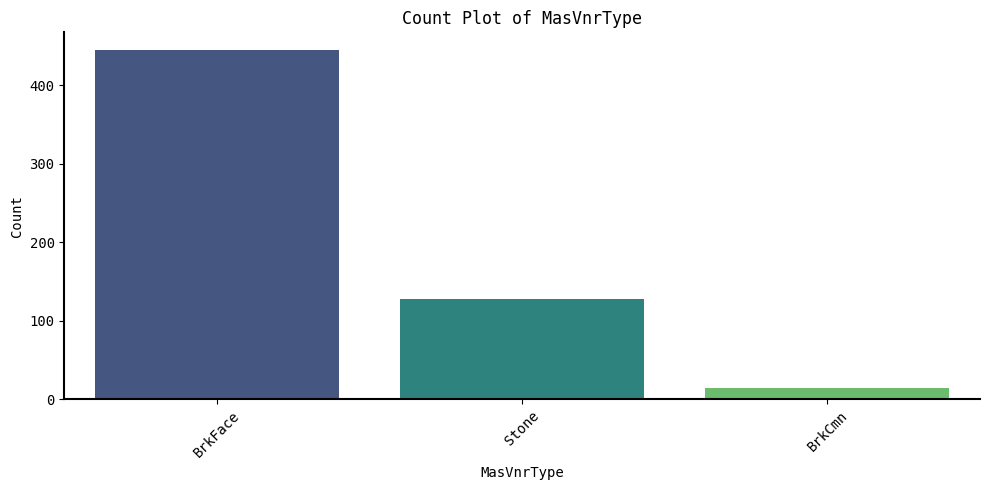

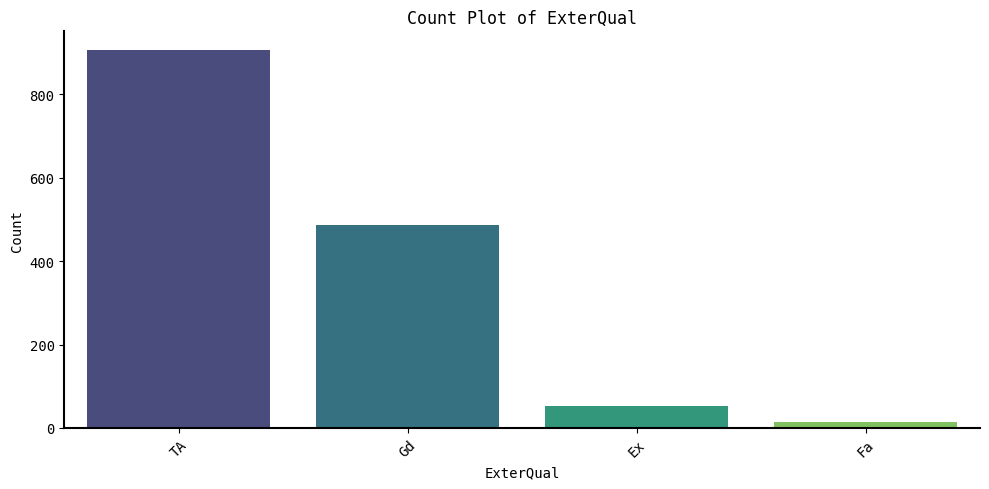

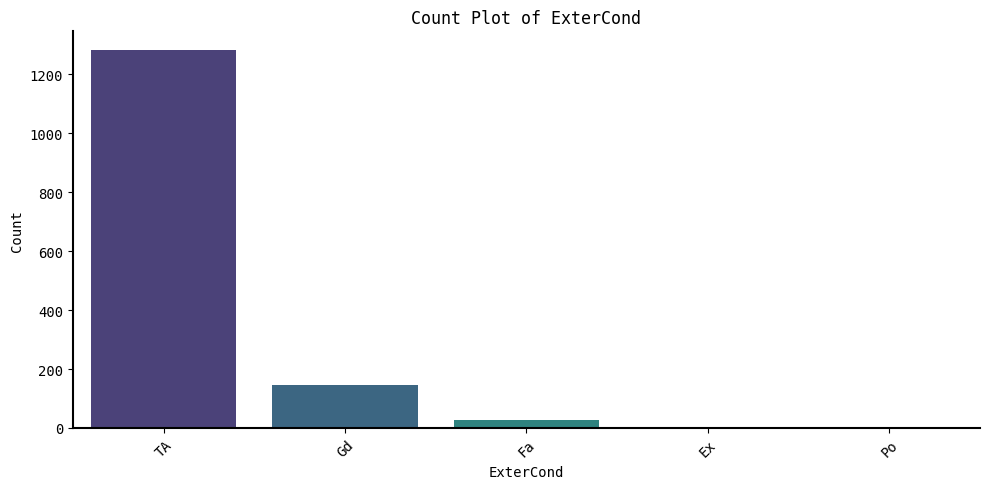

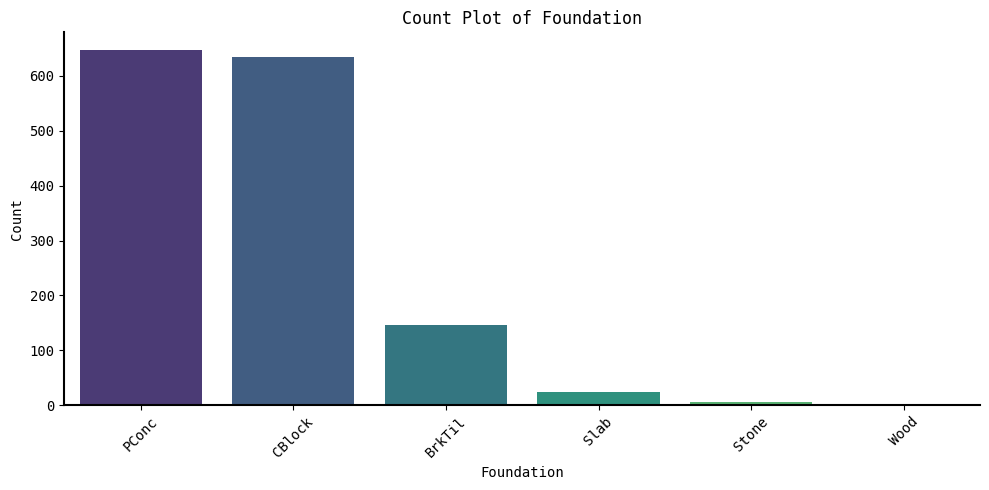

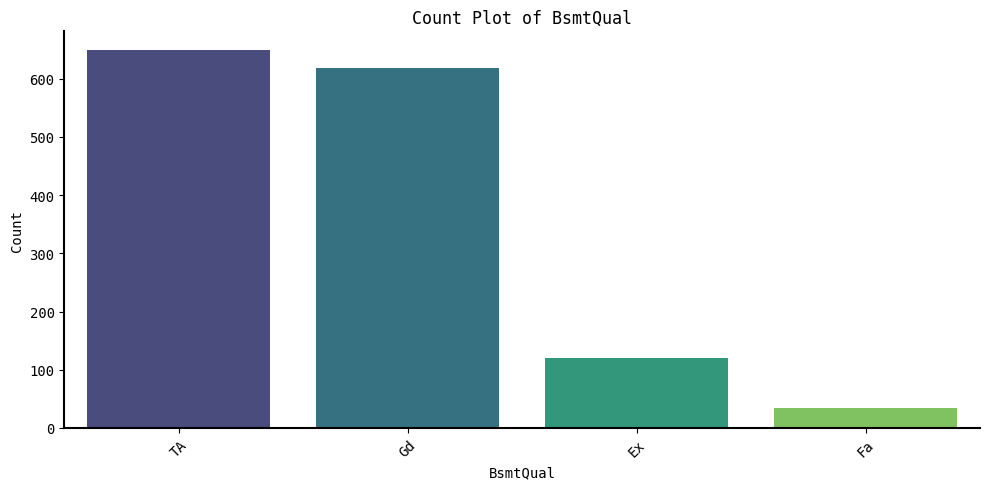

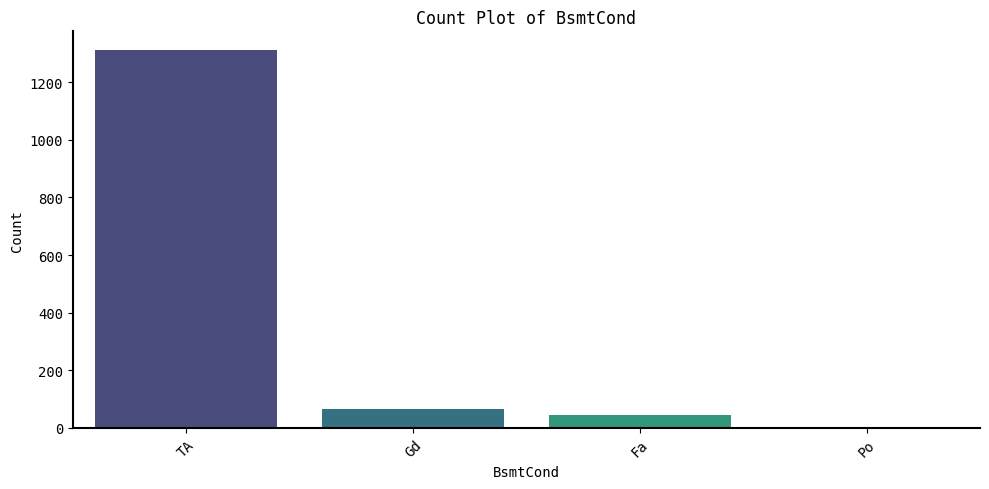

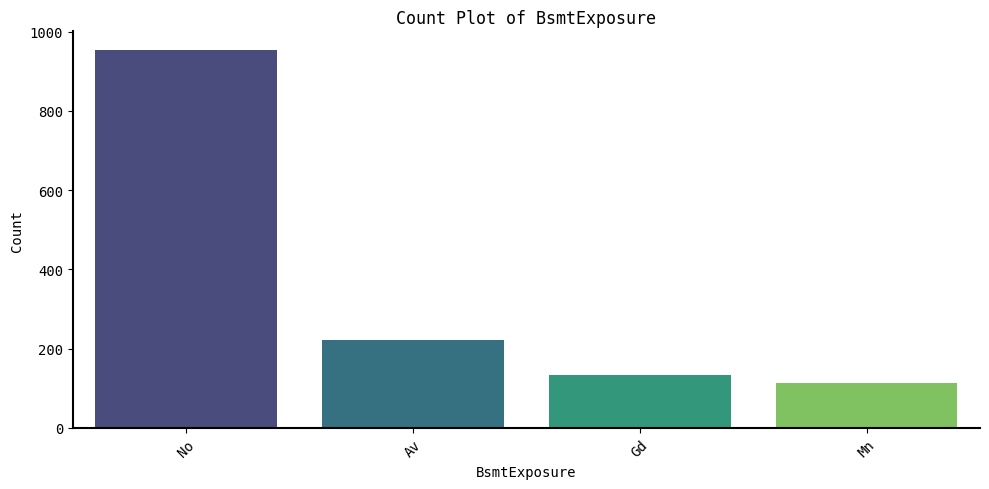

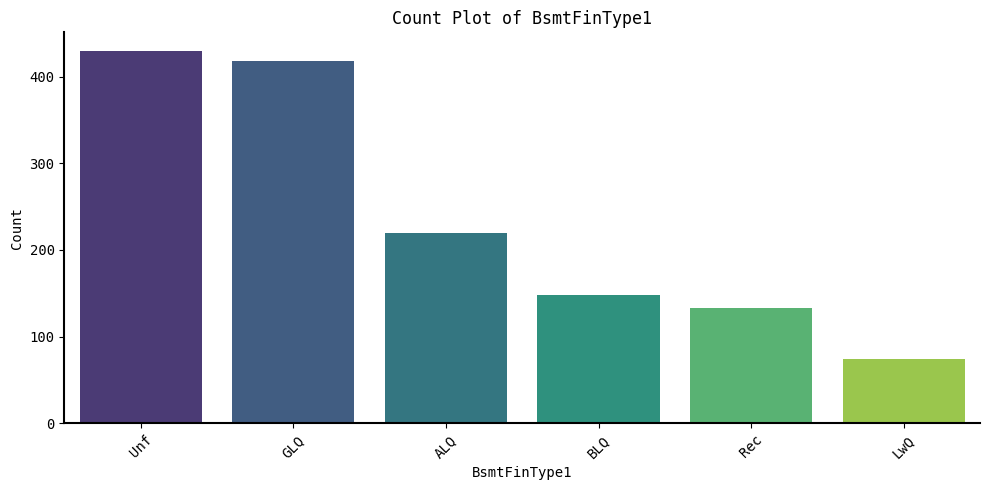

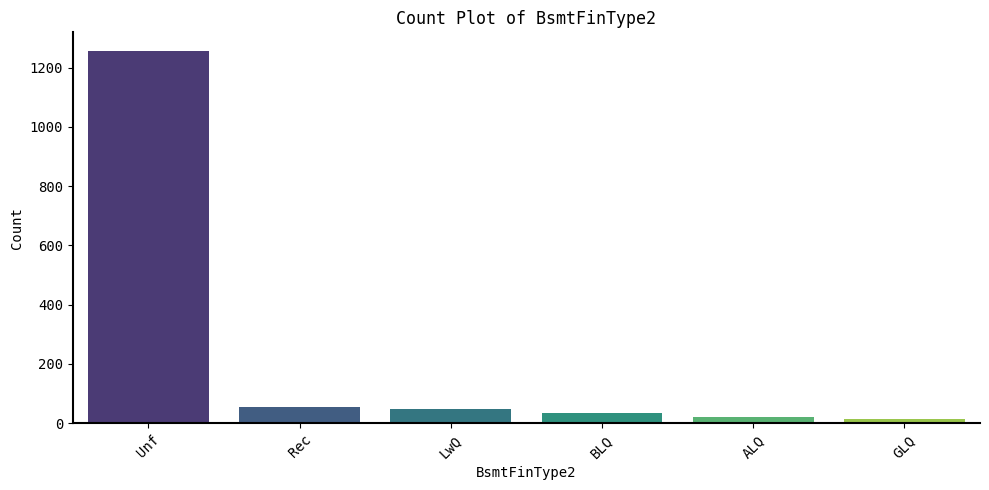

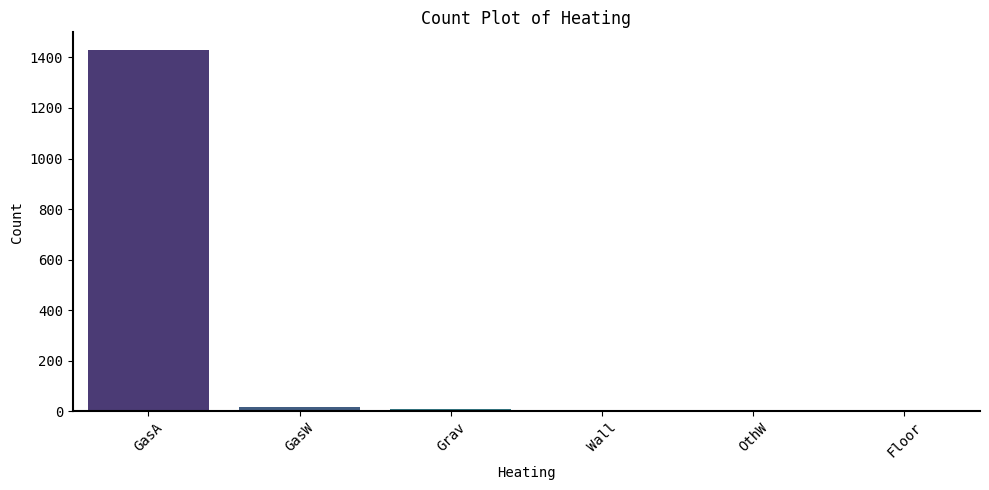

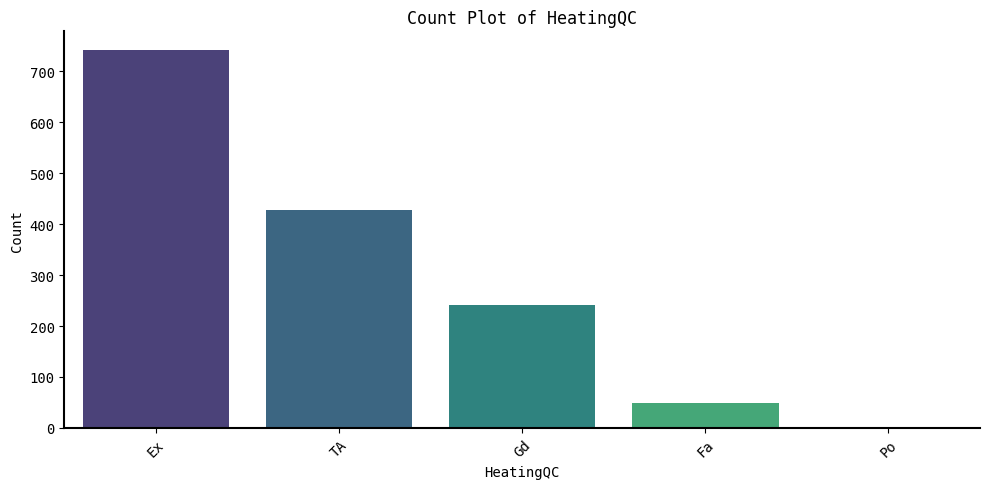

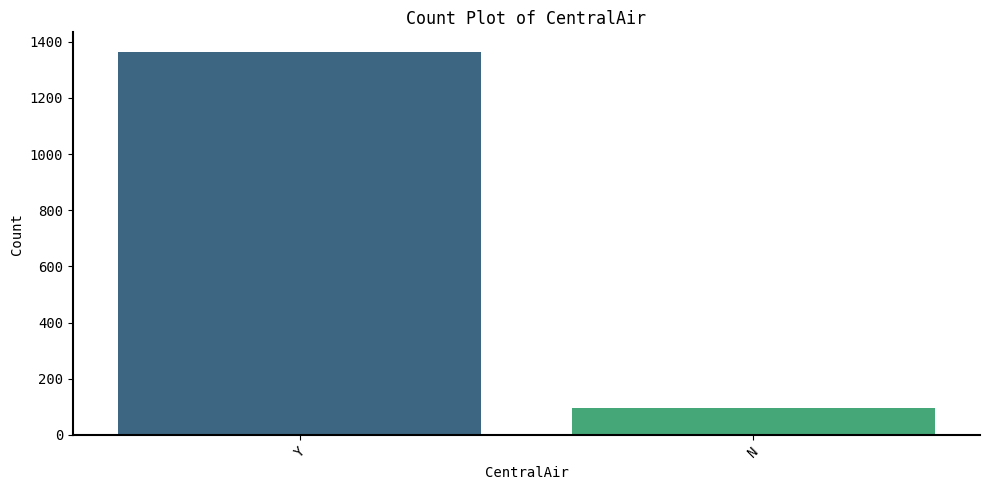

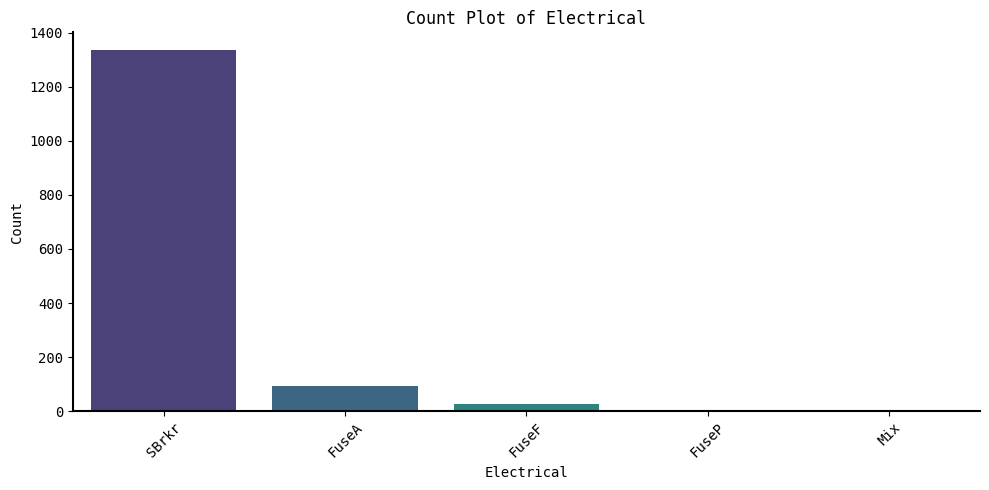

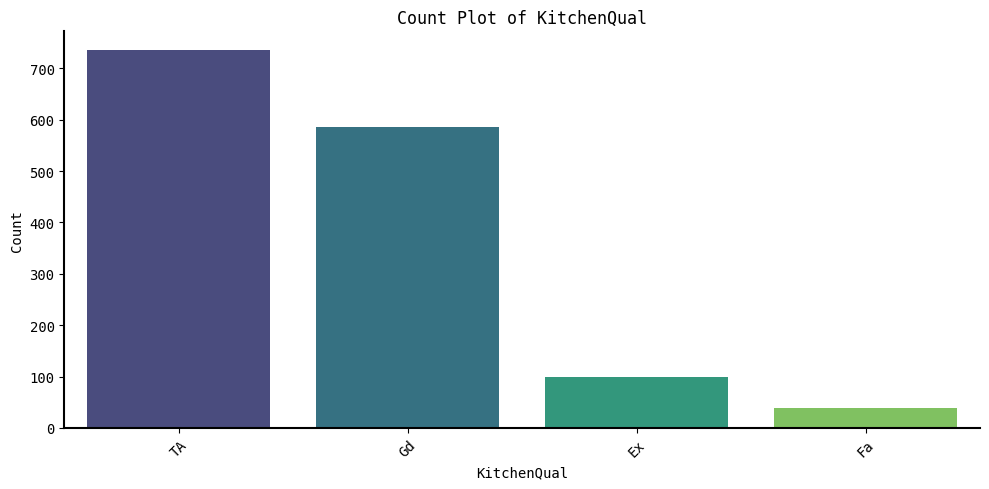

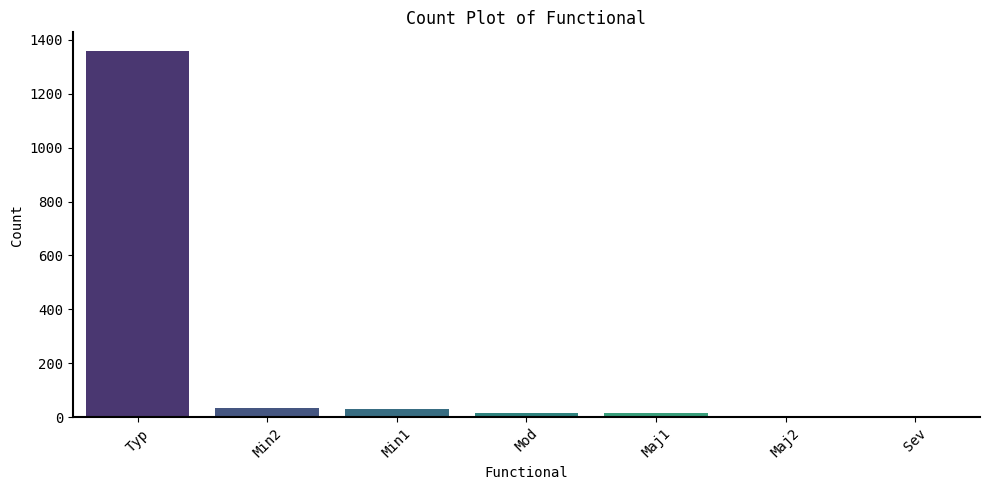

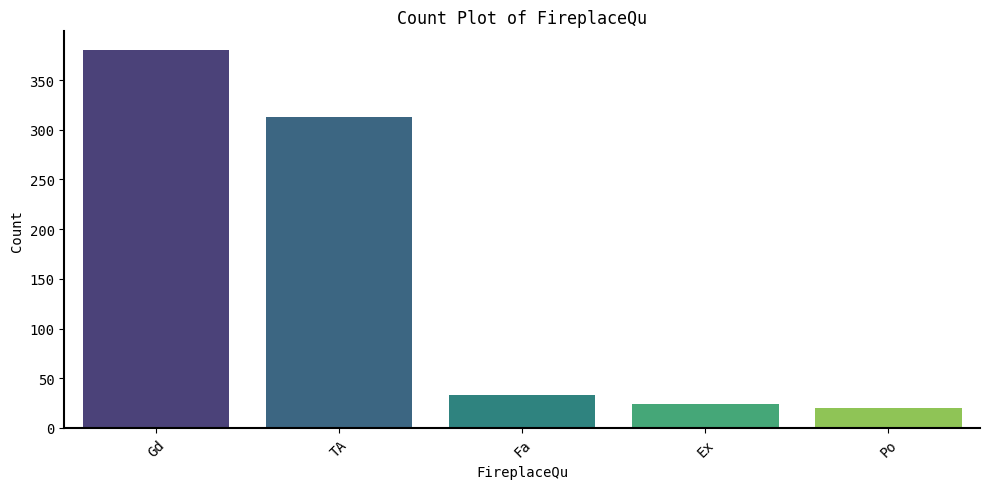

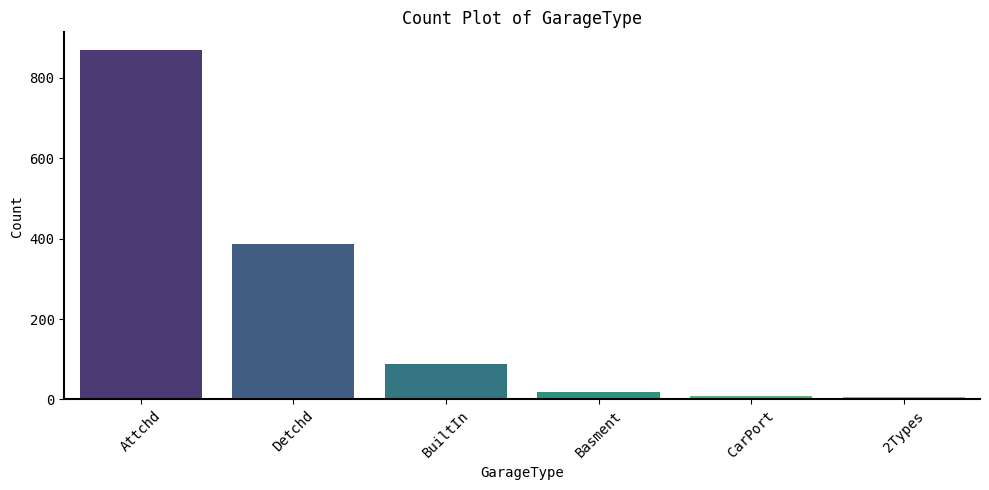

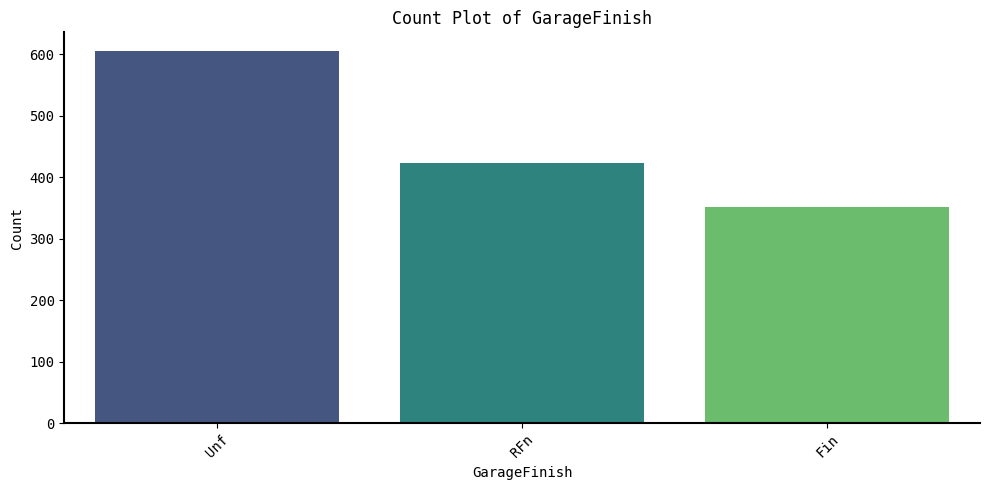

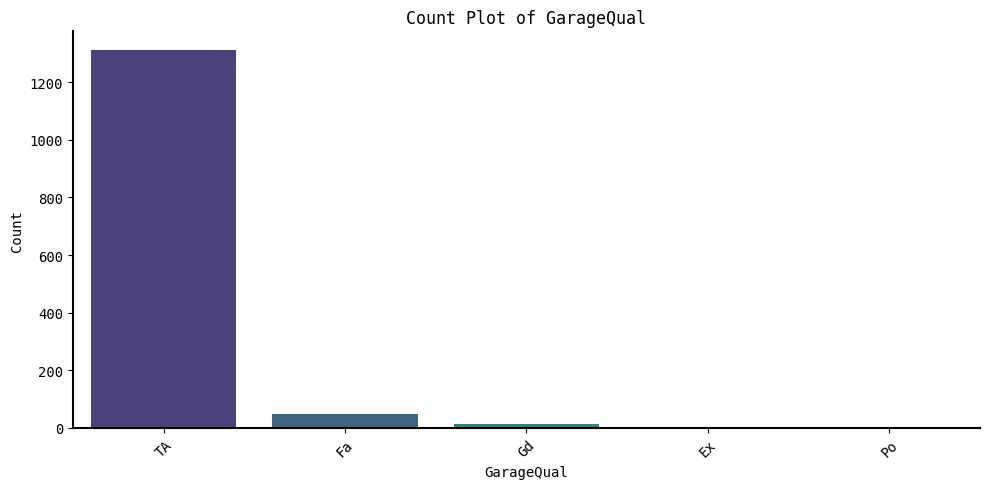

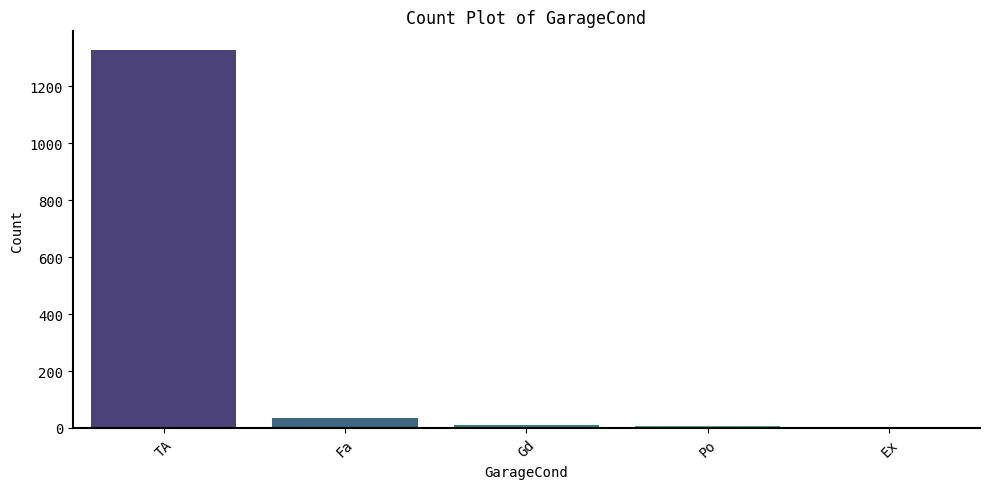

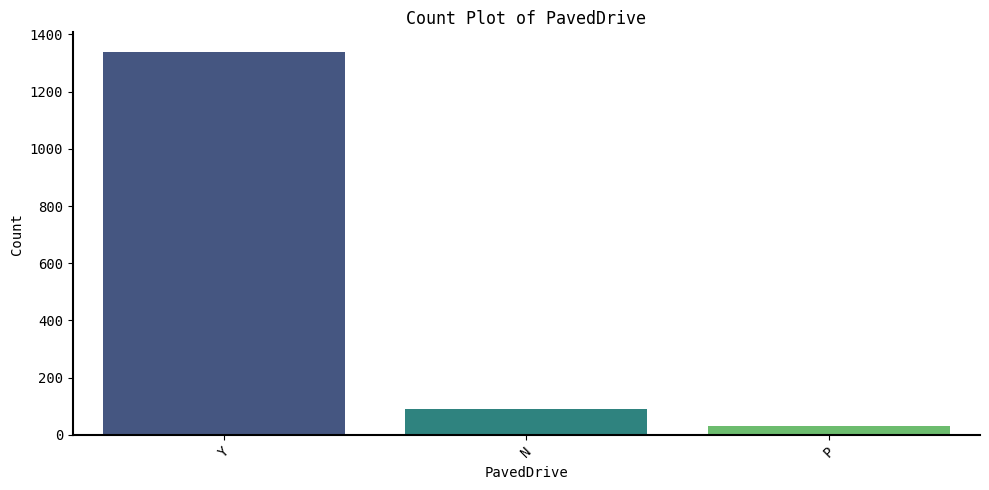

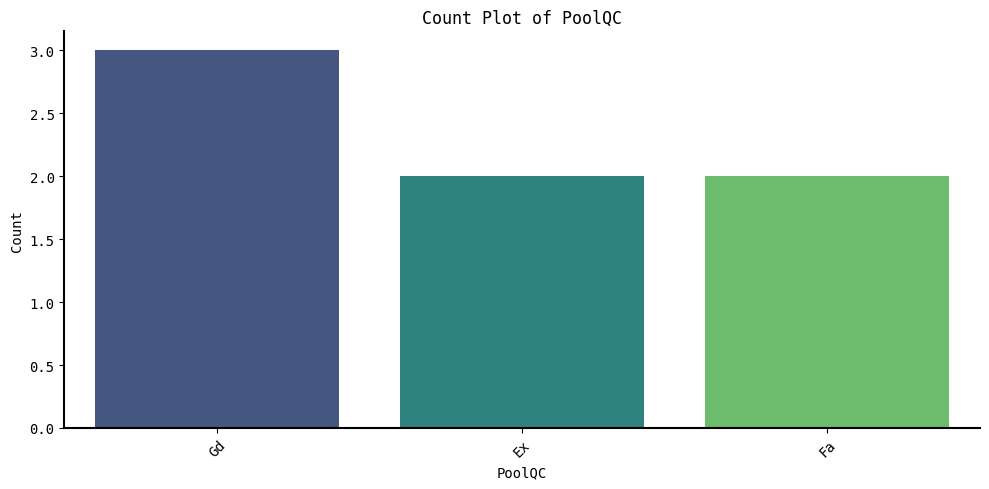

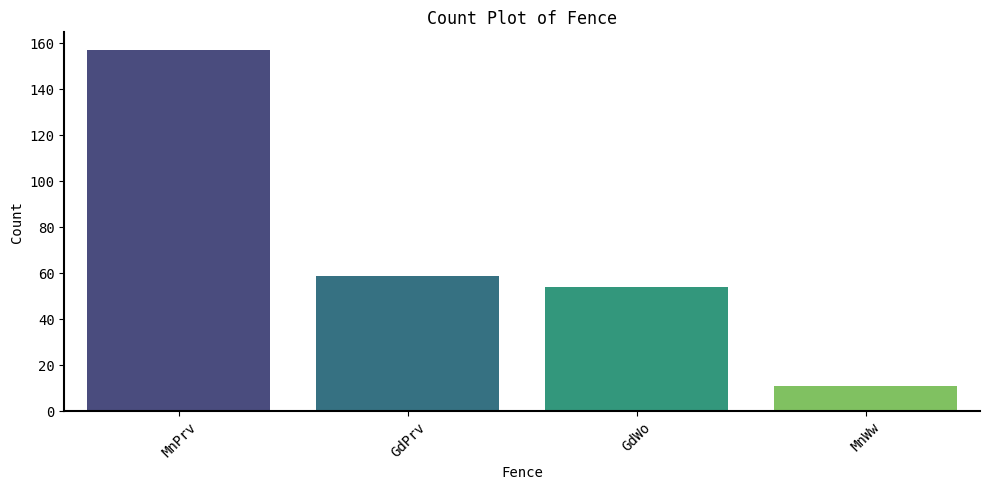

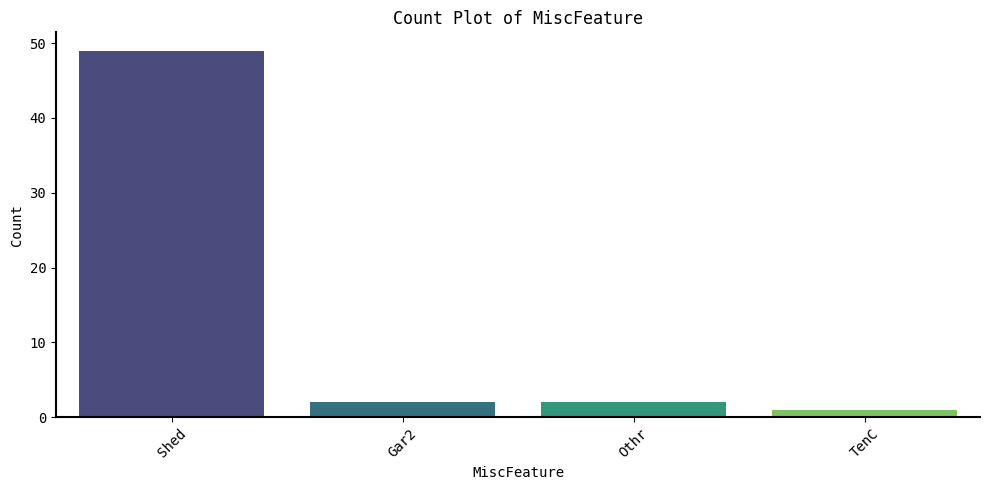

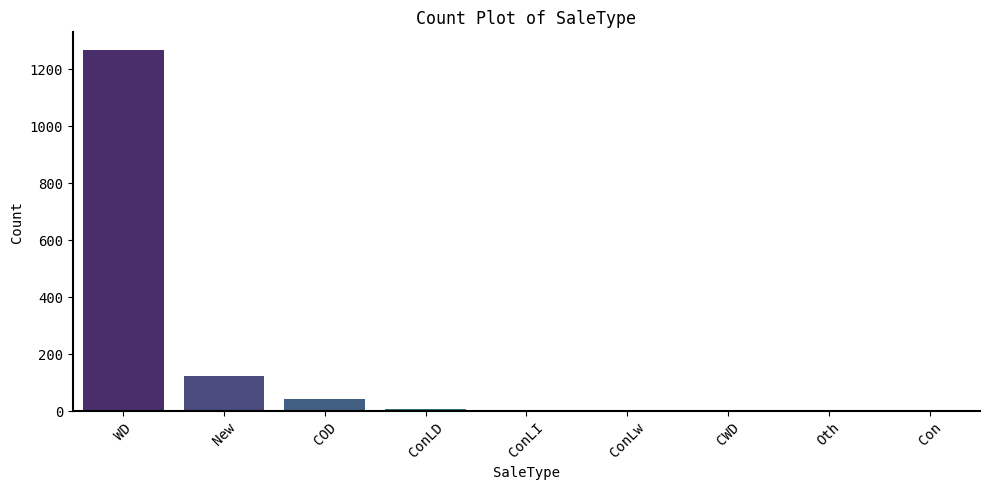

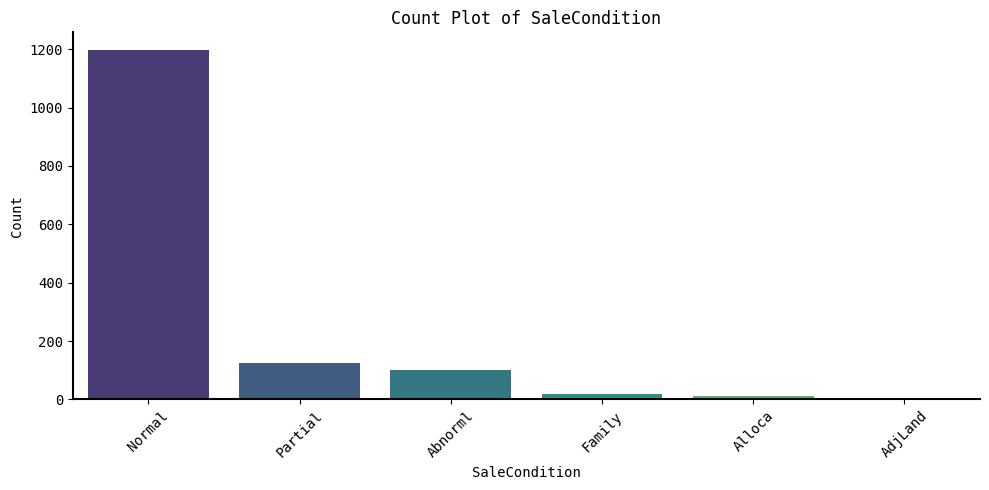

In [11]:
# For Categorical Variables: Count plot for each column
# --------------------------------------------------
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    # Drop NA values for plotting
    sns.countplot(data=house, x=col, order=house[col].value_counts().index, palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

In [12]:
print(f"\nValue counts for {col}:\n", house[col].value_counts())


Value counts for SaleCondition:
 SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64


In [13]:
# Display missing value counts for each column
missing_values = house.isnull().sum().sort_values(ascending=False)
print("Missing Values in each column:\n", missing_values[missing_values > 0])

Missing Values in each column:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageYrBlt       81
GarageType        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtFinType1      37
BsmtQual          37
BsmtCond          37
MasVnrArea         8
Electrical         1
dtype: int64


In [14]:
# Define numerical and categorical columns again
num_cols = house.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = house.select_dtypes(include=['object']).columns.tolist()

In [15]:
# Impute Missing Values for Numerical Columns
# --------------------------------------------------
for col in num_cols:
    if house[col].isnull().sum() > 0:
        median_val = house[col].median()
        house[col].fillna(median_val, inplace=True)
        print(f"Filled missing numeric values in '{col}' with median: {median_val}")

Filled missing numeric values in 'LotFrontage' with median: 69.0
Filled missing numeric values in 'MasVnrArea' with median: 0.0
Filled missing numeric values in 'GarageYrBlt' with median: 1980.0


In [16]:
# Impute Missing Values for Categorical Columns
# --------------------------------------------------
for col in cat_cols:
    if house[col].isnull().sum() > 0:
        house[col].fillna("Missing", inplace=True)
        print(f"Filled missing categorical values in '{col}' with 'Missing'")

Filled missing categorical values in 'Alley' with 'Missing'
Filled missing categorical values in 'MasVnrType' with 'Missing'
Filled missing categorical values in 'BsmtQual' with 'Missing'
Filled missing categorical values in 'BsmtCond' with 'Missing'
Filled missing categorical values in 'BsmtExposure' with 'Missing'
Filled missing categorical values in 'BsmtFinType1' with 'Missing'
Filled missing categorical values in 'BsmtFinType2' with 'Missing'
Filled missing categorical values in 'Electrical' with 'Missing'
Filled missing categorical values in 'FireplaceQu' with 'Missing'
Filled missing categorical values in 'GarageType' with 'Missing'
Filled missing categorical values in 'GarageFinish' with 'Missing'
Filled missing categorical values in 'GarageQual' with 'Missing'
Filled missing categorical values in 'GarageCond' with 'Missing'
Filled missing categorical values in 'PoolQC' with 'Missing'
Filled missing categorical values in 'Fence' with 'Missing'
Filled missing categorical values 

In [17]:
# Verify that missing values have been handled
print("\nTotal Missing Values After Imputation:", house.isnull().sum().sum())


Total Missing Values After Imputation: 0


<div style="background: linear-gradient(135deg, #1e3c72, #2a5298); color: #f0f8ff; font-family: 'Arial', sans-serif; font-weight: bold; text-align: center; border: 3px solid #87ceeb; border-radius: 15px; padding: 15px; width: 300px; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); margin: 20px auto;">
  Feature Engineering
</div>

In [18]:
df = house

In [19]:
# 1. Create a feature for the age of the house at the time of sale
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

In [20]:
# 2. Create a feature for the number of years since the last remodel
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

In [21]:
# 3. Total Floor Area: Sum of 1st and 2nd floor areas (if applicable)
df['TotalFlrSF'] = df['1stFlrSF'] + df['2ndFlrSF']

In [22]:
# 4. Total Bathrooms: Combining full and half baths
# (Assuming half baths count as 0.5 of a full bath)
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])

In [23]:
# 5. Simplify the 'OverallQual' into a categorical quality label
def quality_label(q):
    if q <= 4:
        return 'Low'
    elif q <= 7:
        return 'Medium'
    else:
        return 'High'

df['QualLabel'] = df['OverallQual'].apply(quality_label)

In [24]:
# Verify that new features have been added
print("Newly Engineered Features:")
print(df[['HouseAge', 'RemodAge', 'TotalFlrSF', 'TotalBath', 'QualLabel']].head())

Newly Engineered Features:
   HouseAge  RemodAge  TotalFlrSF  TotalBath QualLabel
0         5         5        1710        3.5    Medium
1        31        31        1262        2.5    Medium
2         7         6        1786        3.5    Medium
3        91        36        1717        2.0    Medium
4         8         8        2198        3.5      High


<div style="background: linear-gradient(135deg, #1e3c72, #2a5298); color: #f0f8ff; font-family: 'Arial', sans-serif; font-weight: bold; text-align: center; border: 3px solid #87ceeb; border-radius: 15px; padding: 15px; width: 300px; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); margin: 20px auto;">
 Model Building and Evaluation
</div>

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

In [26]:
# Define a set of features for modeling
# You can adjust or expand this feature set as needed
features = ['OverallQual', 'GrLivArea', 'TotalBath', 'HouseAge', 'RemodAge', 'TotalFlrSF']
X = df[features]
y = df['SalePrice']

In [27]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Instantiate and fit a Linear Regression model as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [29]:
# Generate predictions on the test set
y_pred = lr_model.predict(X_test)

In [30]:
# Evaluate the model using common regression metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [31]:
print("Linear Regression Model Evaluation:")
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Linear Regression Model Evaluation:
Root Mean Squared Error (RMSE): 42816.32532131719
Mean Absolute Error (MAE): 27628.25697704786
R² Score: 0.7609961213509907


In [32]:
# Cross-Validation for additional robustness
# --------------------------------------------------
cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
print("\nCross-Validated RMSE Scores:", cv_rmse)
print("Mean Cross-Validated RMSE:", cv_rmse.mean())


Cross-Validated RMSE Scores: [35561.9982387  40046.44302689 43323.1622851  36092.23322107
 46707.60429939]
Mean Cross-Validated RMSE: 40346.28821422957


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error

In [34]:
# Define the feature set and target (same as before)
features = ['OverallQual', 'GrLivArea', 'TotalBath', 'HouseAge', 'RemodAge', 'TotalFlrSF']
X = df[features]
y = df['SalePrice']

# Split the data (80-20 split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Instantiate the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

In [36]:
# Set up the hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [37]:
# Set up GridSearchCV to find the best hyperparameters using 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

In [38]:
# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error', verbose=2)

In [39]:
# Output the best hyperparameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [40]:
# Use the best estimator to make predictions on the test set
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

In [41]:
# Evaluate the model on the test set
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE on Test Set:", rmse_rf)

Random Forest RMSE on Test Set: 33081.93169652973


In [42]:
# Additionally, evaluate using cross-validation on the entire dataset
cv_scores_rf = cross_val_score(best_rf, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse_rf = np.sqrt(-cv_scores_rf)
print("Cross-Validated RMSE Scores for Random Forest:", cv_rmse_rf)
print("Mean Cross-Validated RMSE for Random Forest:", cv_rmse_rf.mean())

Cross-Validated RMSE Scores for Random Forest: [30115.02066426 38261.46962255 34352.59541791 26398.78029532
 37606.53381031]
Mean Cross-Validated RMSE for Random Forest: 33346.87996207053


In [43]:
# Calculate feature importances from the best Random Forest model
importances = best_rf.feature_importances_

In [44]:
# Create a DataFrame for easy visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

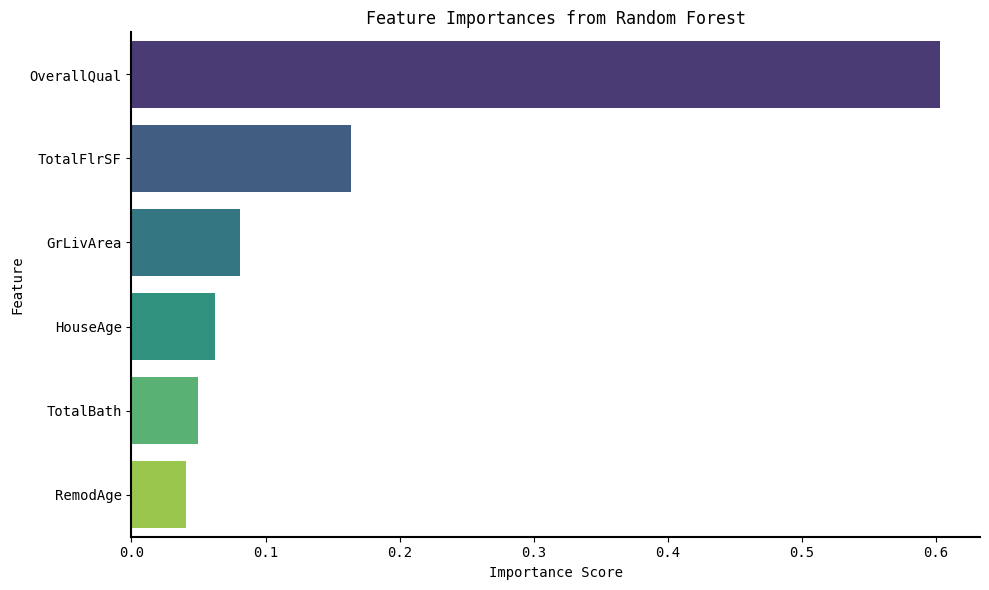

In [45]:
# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [46]:
# Display the importance scores
print(feature_importance_df)

       Feature  Importance
0  OverallQual    0.602594
5   TotalFlrSF    0.163519
1    GrLivArea    0.080850
3     HouseAge    0.062455
2    TotalBath    0.049797
4     RemodAge    0.040786


<div style="background: linear-gradient(135deg, #1e3c72, #2a5298); color: #f0f8ff; font-family: 'Arial', sans-serif; font-weight: bold; text-align: center; border: 3px solid #87ceeb; border-radius: 15px; padding: 15px; width: 300px; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); margin: 20px auto;">
  Submission
</div>

In [47]:
# Load the test dataset
test_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

In [48]:
# Fill missing values in numerical columns using median imputation
num_cols = test_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols:
    if test_df[col].isnull().sum() > 0:
        median_val = test_df[col].median()
        test_df[col].fillna(median_val, inplace=True)

In [49]:
# Fill missing values in categorical columns using a placeholder value
cat_cols = test_df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if test_df[col].isnull().sum() > 0:
        test_df[col].fillna("Missing", inplace=True)

In [50]:
# Create engineered features (make sure these columns exist in test_df)
test_df['HouseAge'] = test_df['YrSold'] - test_df['YearBuilt']
test_df['RemodAge'] = test_df['YrSold'] - test_df['YearRemodAdd']
test_df['TotalFlrSF'] = test_df['1stFlrSF'] + test_df['2ndFlrSF']
test_df['TotalBath'] = (test_df['FullBath'] + 
                        0.5 * test_df['HalfBath'] + 
                        test_df['BsmtFullBath'] + 
                        0.5 * test_df['BsmtHalfBath'])

In [51]:
# Use the same feature set that was used in model training
features = ['OverallQual', 'GrLivArea', 'TotalBath', 'HouseAge', 'RemodAge', 'TotalFlrSF']
X_test_final = test_df[features]

In [52]:
# Here, we use our best Random Forest model (best_rf) obtained from previous tuning steps.
# Ensure that 'best_rf' is already trained in your environment.
predictions = best_rf.predict(X_test_final)

In [53]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': predictions
})

In [54]:
submission.to_csv('submission.csv', index=False)
print("submission.csv file created successfully!")

submission.csv file created successfully!


In [55]:
pdf = pd.read_csv('submission.csv')
pdf

,Id,SalePrice
0,1461,110895.979067
1,1462,145527.598375
2,1463,174023.344305
3,1464,184980.909362
4,1465,196856.484848
...,...,...
1454,2915,103487.823933
1455,2916,103487.823933
1456,2917,147377.402196
1457,2918,137505.288895
